# Notebook 1 of 3: Research foundations for provable betting edges (screen, prove, combine)

A subscription betting business wants three things from its data science: (1) **screen** a long list of candidate signals (referee trends, rest days, travel and the like) without fooling itself, (2) **prove** that a signal or model really beats the market price, in a way that survives continuous monitoring, and (3) **combine** several models into one better forecast. This notebook derives, from first principles and with **Monte Carlo verification of every guarantee**, the statistics behind three papers that answer those three questions:

1. **Prove: Choe and Ramdas, "Comparing Sequential Forecasters"**, *Operations Research* 72(4), 2024, arXiv:2110.00115. Anytime-valid confidence sequences (CS) and e-processes for the average score gap between two forecasters.
2. **Screen: Xu and Ramdas, "Online multiple testing with e-values"** (e-LOND), AISTATS 2024, arXiv:2311.06412. False discovery rate (FDR) control for a stream of hypotheses under arbitrary dependence.
3. **Combine: Chen, Huang, Jordan and Luo, "Calibeating Made Simple"**, arXiv:2603.22167. Calibrating an external forecast and aggregating several of them, with regret-type guarantees.

**Honest framing.** This is a simulation study on synthetic data; it is not betting advice, and its results describe the simulator, not real markets. Nothing here uses real odds, an LLM or a network call. Statements attributed to the papers carry a section, theorem or equation number; everything else is labelled **derived here** (our own simulator, our own toy numbers, our own composition of the three methods). Toy numbers (from our simulator) and paper numbers (quoted from a paper) are always printed in separate, labelled lines. Several of the printed lines are `SELF-CHECK` lines with an explicit threshold and a `MET` / `NOT MET` verdict; a check that fails is reported, not hidden.

**Roadmap.** Section 1 shows why naive backtests lie. Sections 2 and 3 cover the Choe-Ramdas machinery, section 4 e-LOND, section 5 calibeating, and section 6 checks by simulation that the three pieces compose. Sections 2 and 6 also define a small set of reusable functions (cells marked `# EXPORT:`) that Notebook 3 loads.

In [1]:
%matplotlib inline
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy import special, stats, optimize

SEED = 20260920
T0_NOTEBOOK = time.time()

# One palette for the whole notebook, reused in every visualization cell.
PALETTE = {
    "cr":        "#1f77b4",   # blue   : Choe-Ramdas empirical-Bernstein CS / e-process (PROVE)
    "hoeffding": "#7f7f7f",   # grey   : baselines (Hoeffding CS, naive / r-LOND reference)
    "peek":      "#d62728",   # red    : invalid peeking / failures / adversarial cases
    "elond":     "#ff7f0e",   # orange : e-LOND (SCREEN)
    "calib":     "#2ca02c",   # green  : calibeating / multi-calibeating (COMBINE)
    "mix":       "#9467bd",   # purple : the composed pipeline (derived here)
    "truth":     "black",     # black  : targets, thresholds, true values
}
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})


def check(label, what, value, threshold, ok):
    """Print one numbered self-check line; the verdict is computed by the caller, never assumed."""
    print(f"SELF-CHECK {label}: {what} -> {value} (threshold {threshold}) -> {'MET' if ok else 'NOT MET'}")


def mc_se(p, n):
    """Binomial Monte Carlo standard error."""
    return float(np.sqrt(max(p * (1 - p), 1e-12) / n))


print("setup done; numpy", np.__version__)

setup done; numpy 2.5.3


## 0. Three papers, three different guarantees

The three papers guarantee three different things, and the rest of the notebook keeps them apart. The table separates what each paper states from what this notebook adds.

| | Choe and Ramdas (PROVE) | Xu and Ramdas (SCREEN) | Chen, Huang, Jordan, Luo (COMBINE) |
|---|---|---|---|
| **Object** | Mean score gap $\Delta_t$ between two forecasters (Eq. 8), tested against the weak null $H_0^w$ (Eq. 18) | A stream of hypotheses $H_1, H_2,\dots$ with e-values $E_t$ satisfying $\mathbb{E}[E_t]\le 1$ under the null (Eq. 3) | Cumulative loss $L_T$ of a learner versus the refinement score $R_T$ of an external forecaster (Def. 2.1) |
| **Guarantee** | **Time-uniform** coverage $P(\exists t:\Delta_t\notin C_t)\le\alpha$ (Eq. 2) and e-process validity at **any stopping time** (Eq. 23) | $\mathrm{FDR}(R_t)\le\alpha$ **at every step $t$** under **arbitrary dependence** (Thm 1) | **Finite-horizon regret-type rates**, e.g. $L_T\le R_T+|Q|\,\alpha(T/|Q|)$ (Thm 3.1), against an **oblivious adversary** |
| **Nature** | Nonasymptotic, distribution-free | Nonasymptotic, no dependence assumption | Nonasymptotic worst-case bounds over sequences fixed in advance |
| **Evidence in the paper** | Simulations, MLB games, precipitation forecasts | Simulations, drug-property application | **Theory only: no experiments and no released code** |
| **Not claimed** | Nothing about future edge (descriptive, not predictive), nothing about profit | Nothing about which hypotheses are non-null, nor about data-dependent ordering | Nothing about coverage or FDR; the bounds are about loss |

All entries in the table are paper facts (Choe and Ramdas Sec. 3.1, 4.4; Xu and Ramdas Sec. 1, 3.2; Chen et al. Sec. 2 to 4). The **Brier score is not profit**: none of the three papers models margin, odds, stakes, costs or betting limits, so every money-related statement in Notebooks 2 and 3 is **derived here**.

## 1. Why naive backtests lie (derived here)

**Claim (derived here, standard multiplicity arithmetic, not a paper claim).** Suppose we backtest $K$ candidate signals that all have **no** real edge, each with a two-sided test at the 5% level (reject when $|z|>1.96$). If the tests are independent, the chance that *at least one* signal looks significant is
$$P(\text{at least one } |z_k|>1.96)=1-0.95^K,$$
which is $\approx 0.87$ for $K=40$. The best of the $K$ statistics is also biased upward: for independent standard normals the expected maximum $\mathbb{E}\max_k|z_k|$ grows roughly like $\sqrt{2\ln K}$. So "the best backtest" of a long candidate list is a strongly selected number, and a single-signal $p$-value no longer means what it says. Section 4 (e-LOND) is the paper-backed remedy; here we only quantify the problem, and also show the classical Bonferroni correction as a contrast.

In [2]:
rng = np.random.default_rng(SEED + 1)
Z975 = stats.norm.ppf(0.975)
Ks = [1, 2, 5, 10, 20, 40, 80, 160, 320]
REPS_S1 = 20_000

s1 = {"K": Ks, "p_any_mc": [], "p_any_theory": [], "emax_mc": [], "emax_approx": [], "median_max_exact": [],
      "bonf_p_any_mc": []}
for K in Ks:
    z = rng.standard_normal((REPS_S1, K))
    mx = np.abs(z).max(axis=1)
    s1["p_any_mc"].append(float((mx > Z975).mean()))
    s1["p_any_theory"].append(1 - 0.95 ** K)
    s1["emax_mc"].append(float(mx.mean()))
    s1["emax_approx"].append(float(np.sqrt(2 * np.log(K))) if K > 1 else 0.0)
    # exact median of max|z|: (2*Phi(x)-1)^K = 1/2
    s1["median_max_exact"].append(float(stats.norm.ppf((1 + 0.5 ** (1.0 / K)) / 2)))
    zb = stats.norm.ppf(1 - 0.05 / (2 * K))              # Bonferroni-corrected two-sided cut-off
    s1["bonf_p_any_mc"].append(float((mx > zb).mean()))

print(f"{'K':>5} {'P(any) MC':>10} {'1-0.95^K':>10} {'E max|z|':>10} {'sqrt(2lnK)':>11} {'median exact':>13} {'Bonferroni P(any)':>18}")
for i, K in enumerate(Ks):
    print(f"{K:5d} {s1['p_any_mc'][i]:10.4f} {s1['p_any_theory'][i]:10.4f} {s1['emax_mc'][i]:10.3f} "
          f"{s1['emax_approx'][i]:11.3f} {s1['median_max_exact'][i]:13.3f} {s1['bonf_p_any_mc'][i]:18.4f}")

i40 = Ks.index(40)
check("1a", "K=40 null signals: P(at least one |z|>1.96), formula 1-0.95^K", f"{1 - 0.95**40:.4f}", "within 0.005 of 0.87",
      abs((1 - 0.95 ** 40) - 0.87) < 0.005)
dev = max(abs(a - b) / mc_se(b, REPS_S1) for a, b in zip(s1["p_any_mc"], s1["p_any_theory"]))
check("1b", "Monte Carlo P(any) matches the formula for every K, worst deviation in MC standard errors", f"{dev:.2f}", "<= 3.5", dev <= 3.5)
ratio = [s1["emax_mc"][i] / s1["emax_approx"][i] for i, K in enumerate(Ks) if K >= 20]
check("1c", "E[max|z|] increases with K and stays within 15% of sqrt(2 ln K) for K>=20 (ratios)",
      f"increasing={bool(np.all(np.diff(s1['emax_mc']) > 0))}, ratio range {min(ratio):.2f}-{max(ratio):.2f}",
      "increasing and ratio in [0.85, 1.15]", bool(np.all(np.diff(s1["emax_mc"]) > 0)) and 0.85 <= min(ratio) and max(ratio) <= 1.15)
bonf_ok = all(p <= 0.05 + 3 * mc_se(0.05, REPS_S1) for p in s1["bonf_p_any_mc"])
check("1d", "Bonferroni cut-off keeps P(any false positive) <= 0.05 for every K (max over K)", f"{max(s1['bonf_p_any_mc']):.4f}",
      f"<= {0.05 + 3 * mc_se(0.05, REPS_S1):.4f}", bonf_ok)

    K  P(any) MC   1-0.95^K   E max|z|  sqrt(2lnK)  median exact  Bonferroni P(any)
    1     0.0518     0.0500      0.804       0.000         0.674             0.0518
    2     0.0982     0.0975      1.126       1.177         1.052             0.0507
    5     0.2279     0.2262      1.573       1.794         1.516             0.0508
   10     0.3979     0.4013      1.879       2.146         1.832             0.0469
   20     0.6349     0.6415      2.159       2.448         2.119             0.0483
   40     0.8750     0.8715      2.430       2.716         2.383             0.0496
   80     0.9831     0.9835      2.670       2.960         2.626             0.0489
  160     0.9998     0.9997      2.899       3.186         2.854             0.0485
  320     1.0000     1.0000      3.112       3.397         3.067             0.0493
SELF-CHECK 1a: K=40 null signals: P(at least one |z|>1.96), formula 1-0.95^K -> 0.8715 (threshold within 0.005 of 0.87) -> MET
SELF-CHECK 1b: Monte Carlo P(any)

**How to read this chart**

Left panel: x is the number $K$ of candidate signals with no real edge (log scale); y is the probability that at least one of them passes a naive $|z|>1.96$ screen. The black curve is $1-0.95^K$ and the dots are the Monte Carlo estimates; they coincide. The red line at 0.05 is what a single test promises; by $K=40$ the naive screen has an 87% chance of producing a "winner" from pure noise. The green curve shows that a Bonferroni-corrected cut-off holds the family-wise error at 5%. Right panel: the average best $|z|$ among $K$ null signals (dots) tracks the $\sqrt{2\ln K}$ growth (dashed) and quickly exceeds 1.96, so the headline number of a best-of-$K$ backtest is inflated by selection alone. For the project: any screen over many signals needs a multiplicity-aware procedure (Section 4), and any proof about a single chosen signal needs a guarantee that survives repeated looking (Sections 2 and 3).

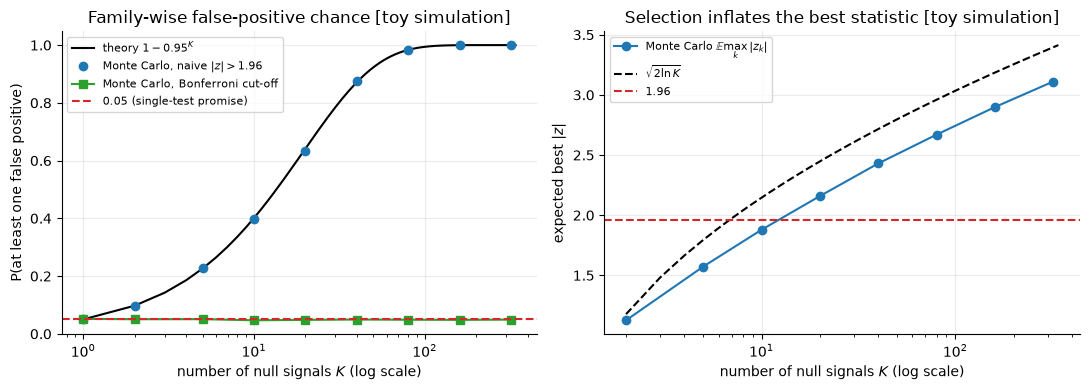

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
Kf = np.array(s1["K"])
kk = np.arange(1, 341)
ax[0].plot(kk, 1 - 0.95 ** kk, color=PALETTE["truth"], label=r"theory $1-0.95^K$")
ax[0].plot(Kf, s1["p_any_mc"], "o", color=PALETTE["cr"], label="Monte Carlo, naive $|z|>1.96$")
ax[0].plot(Kf, s1["bonf_p_any_mc"], "s-", color=PALETTE["calib"], label="Monte Carlo, Bonferroni cut-off")
ax[0].axhline(0.05, color=PALETTE["peek"], ls="--", label="0.05 (single-test promise)")
ax[0].set_xscale("log"); ax[0].set_xlabel("number of null signals $K$ (log scale)")
ax[0].set_ylabel("P(at least one false positive)"); ax[0].set_title("Family-wise false-positive chance [toy simulation]")
ax[0].legend(fontsize=8)
ax[1].plot(Kf[1:], s1["emax_mc"][1:], "o-", color=PALETTE["cr"], label=r"Monte Carlo $\mathbb{E}\max_k|z_k|$")
ax[1].plot(kk[1:], np.sqrt(2 * np.log(kk[1:])), "--", color=PALETTE["truth"], label=r"$\sqrt{2\ln K}$")
ax[1].axhline(Z975, color=PALETTE["peek"], ls="--", label="1.96")
ax[1].set_xscale("log"); ax[1].set_xlabel("number of null signals $K$ (log scale)"); ax[1].set_ylabel(r"expected best $|z|$")
ax[1].set_title("Selection inflates the best statistic [toy simulation]"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2. PROVE: comparing two forecasters with anytime-valid confidence sequences (Choe and Ramdas)

**The game (Sec. 4.1, Game 1).** At each round $t$ forecaster 1 and forecaster 2 issue forecasts $p_t,q_t$; Reality (which may be adaptive and needs no stationarity) picks $r_t=\mathbb{E}_{t-1}[y_t]$ (Eq. 7); then $y_t\sim r_t$ is revealed. With a proper score $S$ (we use the Brier score $S(p,y)=1-(p-y)^2$, so higher is better and a positive gap means forecaster 1 is better):

* target: $\Delta_t=\frac1t\sum_{i\le t}\delta_i$ with $\delta_i=\mathbb{E}_{i-1}[S(p_i,y_i)-S(q_i,y_i)]$ (Eq. 8), a **moving, data-dependent** quantity, not a fixed parameter;
* estimator: $\hat\Delta_t=\frac1t\sum_{i\le t}\hat\delta_i$ with $\hat\delta_i=S(p_i,y_i)-S(q_i,y_i)$ (Eq. 9);
* the error $S_t=t(\hat\Delta_t-\Delta_t)=\sum_{i\le t}(\hat\delta_i-\delta_i)$ (Eq. 10) is a martingale.

**Time-uniform inference (Sec. 3.1, 4.3).** A test supermartingale $L_t$ ($L_0=1$, nonnegative) satisfies **Ville's inequality** $P(\exists t:L_t\ge 1/\alpha)\le\alpha$ (Eq. 1). A $(1-\alpha)$ confidence sequence satisfies $P(\exists t:\theta_t\notin C_t)\le\alpha$ (Eq. 2), which is equivalent to validity at every stopping time: "for all stopping times $\tau$, possibly infinite, $P(\theta_\tau\in C_\tau)\ge1-\alpha$" (Eq. 3). A one-sided **uniform boundary** $u$ (Eq. 11) is a function of the *intrinsic time* $\hat V_t$ with $P(\forall t:S_t\le u(\hat V_t))\ge1-\alpha_{\rm side}$. Two results turn it into a CS:

* **Thm 1 (Hoeffding-style CS, Eq. 14).** If $\hat\delta_i$ is $c$-sub-Gaussian given the past, $\hat\Delta_t\pm u(t)/t$ is a $(1-\alpha)$-CS, with $u$ a sub-Gaussian boundary at crossing probability $\alpha/2$. The normal-mixture boundary is $u(v)=\sqrt{(v+\rho)\log\frac{v+\rho}{\alpha^2\rho}}$ (Eq. 17; $v=c^2t$ here).
* **Thm 2 (empirical-Bernstein CS, Eq. 15).** If $|\hat\delta_i|\le c/2$, take $\hat V_t=\sum_{i\le t}(\hat\delta_i-\gamma_i)^2$ with any predictable $\gamma_i\in[-c/2,c/2]$; then $C_t^{\rm EB}=\hat\Delta_t\pm u(\hat V_t)/t$ is a $(1-\alpha)$-CS for $\Delta_t$, with $u$ a sub-exponential boundary at crossing probability $\alpha/2$. The paper's default is $\gamma_i=\hat\Delta_{i-1}$ (Sec. 4.3.3) and the default boundary is the **gamma-exponential mixture** (Sec. 4.3.4, App. B.1). For the Brier score $|\hat\delta_i|\le1$, hence $c=2$.

**The gamma-exponential boundary.** It is $u(v)=\sup\{s:m(s,v)<1/\alpha_{\rm side}\}$ (Eq. 16), where $m(s,v)=\int\exp\{\lambda s-\psi_{E,c}(\lambda)v\}f_\rho(\lambda)\,d\lambda$ (Eq. 41) mixes the exponential supermartingales over a gamma density. With $a=\frac{v+\rho}{c^2}$ and $b=\frac{cs+v+\rho}{c^2}$, App. B.1 (Prop. 3, Eq. 43) gives, for $b>0$, the closed form
$$m(s,v)=C\!\left(\tfrac{\rho}{c^2}\right)\Gamma(a)\,\gamma(a,b)\,b^{-a}\exp\!\left\{\tfrac{cs+v}{c^2}\right\},$$
with $\gamma$ the regularized lower incomplete gamma function and $C(\rho')=\rho'^{\rho'}/(\gamma(\rho',\rho')\Gamma(\rho'))$. The single tuning parameter is set from the intrinsic time $v_{\rm opt}$ at which the boundary should be tightest, $\rho=v_{\rm opt}/\big(2\log(1/\alpha)+\log(1+2\log(1/\alpha))\big)$ (App. B.1; the authors' released code reads it as the two-sided tuning at level $\alpha$, i.e. $2\alpha_{\rm side}$), and the paper's default is $v_{\rm opt}=10$ (App. I.4), $\alpha=0.05$. Two facts are **derived here**: the trace does not spell out $\psi_{E,c}(\lambda)=(-\log(1-c\lambda)-c\lambda)/c^2$ (the sub-exponential function of Howard et al. 2021), and for $b\le 0$ it only says $m\le1$, so we use the Euler-integral identity $m=C\,e^{-\rho'}\,{}_1F_1(1;a+1;b)/a$ there. Both are checked against numerical integration below.

**Speed.** The boundary depends on the data only through the scalar $v$, so it is solved once on a grid of $v$ (bisection on the monotone map $s\mapsto m(s,v)$) and **interpolated**; the whole confidence sequence for thousands of paths is then a few vectorized array operations. The three cells below are exported (marked `# EXPORT:`) for Notebook 3.

In [4]:
# EXPORT: cr_boundary
import numpy as np
from functools import lru_cache
from scipy import special as _sp


def _cr_rho(alpha_side, v_opt):
    """Tuning map of App. B.1: rho = v_opt / (2 log(1/a) + log(1 + 2 log(1/a))) with a = 2 alpha_side."""
    a = 2.0 * alpha_side
    L = np.log(1.0 / a)
    return float(v_opt / (2.0 * L + np.log(1.0 + 2.0 * L)))


def _cr_log_m(s, v, rho, c=2.0):
    """log of the gamma-exponential mixture m(s, v) (Eq. 41, closed form Eq. 43 for b > 0).
    For b <= 0 (where the trace only says m <= 1) we use the Euler-integral identity
    m = C' exp(-rho') 1F1(1; a+1; b) / a  (derived here, checked against quadrature)."""
    s, v = np.broadcast_arrays(np.asarray(s, dtype=float), np.asarray(v, dtype=float))
    rp = rho / c ** 2                                  # rho' = rho / c^2
    a = (v + rho) / c ** 2
    b = (c * s + v + rho) / c ** 2
    logC = rp * np.log(rp) - np.log(_sp.gammainc(rp, rp)) - _sp.gammaln(rp)
    out = np.empty(s.shape)
    pos = b > 0
    with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
        ap, bp = a[pos], b[pos]
        eq43 = (logC + _sp.gammaln(ap) + np.log(_sp.gammainc(ap, bp)) - ap * np.log(bp)
                + (c * s[pos] + v[pos]) / c ** 2)
        bad = ~np.isfinite(eq43)                        # gammainc underflow -> 1F1 identity
        if bad.any():
            eq43[bad] = (logC - rp + np.log(_sp.hyp1f1(1.0, ap[bad] + 1.0, np.minimum(bp[bad], 700.0)))
                         - np.log(ap[bad]))
        out[pos] = eq43
        nz = ~pos
        an, bn = a[nz], b[nz]
        out[nz] = logC - rp + np.log(_sp.hyp1f1(1.0, an + 1.0, bn)) - np.log(an)
    return out


@lru_cache(maxsize=32)
def _cr_grid(alpha_side, c, v_opt, rho_override=None):
    rho = _cr_rho(alpha_side, v_opt) if rho_override is None else rho_override
    vg = np.concatenate([[0.0], np.geomspace(1e-2, 1e7, 3000)])
    target = -np.log(alpha_side)
    lo = -(vg + rho) / c                                  # b = 0 -> m <= 1 < 1/alpha
    hi = np.full_like(vg, 4.0 * c * target + 10.0)
    while np.any(_cr_log_m(hi, vg, rho, c) < target):
        hi = hi * 2.0
    for _ in range(60):                                   # bisection on the monotone map s -> m(s, v)
        mid = 0.5 * (lo + hi)
        below = _cr_log_m(mid, vg, rho, c) < target
        lo = np.where(below, mid, lo)
        hi = np.where(below, hi, mid)
    return vg, 0.5 * (lo + hi)


def cr_uniform_boundary(v, alpha_side=0.025, c=2.0, v_opt=10.0, rho=None):
    """One-sided gamma-exponential-mixture uniform boundary u(v) with crossing probability
    alpha_side and scale c (Sec. 4.3.4 / App. B.1). Depends only on the intrinsic time v, so it is
    computed once on a grid and interpolated (vectorised over any array shape). `rho` optionally overrides the
    tuning parameter that is otherwise derived from (alpha_side, v_opt)."""
    vg, ug = _cr_grid(float(alpha_side), float(c), float(v_opt), None if rho is None else float(rho))
    v = np.asarray(v, dtype=float)
    u = np.interp(v, vg, ug)
    big = v > vg[-1]
    if np.any(big):                                       # sqrt-rate extrapolation beyond the grid
        u = np.where(big, ug[-1] * np.sqrt(np.maximum(v, 1e-300) / vg[-1]), u)
    return u

In [5]:
# EXPORT: cr_confseq
# (depends on the cr_boundary cell: uses cr_uniform_boundary)
import numpy as np


def cr_confseq(delta_hat, alpha=0.05, c=2.0, v_opt=10.0):
    """(1-alpha) empirical-Bernstein confidence sequence (Thm 2, Eq. 15) for the average score
    differential Delta_t. delta_hat has shape (..., T): S(p_t,y_t) - S(q_t,y_t), positive = p better,
    with |delta_hat| <= c/2. Predictable centring gamma_i = Delta-hat_{i-1} (Sec. 4.3.3), Delta-hat_0 = 0.
    Returns (lower, upper), each of shape (..., T) for t = 1..T."""
    d = np.asarray(delta_hat, dtype=float)
    t = np.arange(1, d.shape[-1] + 1, dtype=float)
    csum = np.cumsum(d, axis=-1)
    dbar = csum / t
    gamma = np.concatenate([np.zeros(d.shape[:-1] + (1,)), dbar[..., :-1]], axis=-1)
    vhat = np.cumsum((d - gamma) ** 2, axis=-1)
    u = cr_uniform_boundary(vhat, alpha_side=alpha / 2.0, c=c, v_opt=v_opt)
    return dbar - u / t, dbar + u / t

In [6]:
# EXPORT: cr_eprocess
# (depends on the cr_boundary cell: uses _cr_rho and _cr_log_m)
import numpy as np


def cr_log_eprocess(delta_hat, c=2.0, v_opt=10.0, alpha=0.05, last_only=False):
    """log E_t^mix, the gamma-exponential mixture e-process (Thm 3, Prop. 3) for the weak null
    H0^w(p, q): Delta_t <= 0 for all t. E_t^mix = m(sum_i delta_hat_i, V-hat_t) with the same
    predictable gamma_i = Delta-hat_{i-1} as the CS. `alpha` only fixes rho via the boundary's
    alpha_side = alpha/2, so that {CS lower bound > 0} = {E_t^mix >= 2/alpha}.
    delta_hat: (..., T). Returns (..., T), or (...) if last_only=True."""
    d = np.asarray(delta_hat, dtype=float)
    t = np.arange(1, d.shape[-1] + 1, dtype=float)
    dbar = np.cumsum(d, axis=-1) / t
    gamma = np.concatenate([np.zeros(d.shape[:-1] + (1,)), dbar[..., :-1]], axis=-1)
    vhat = np.cumsum((d - gamma) ** 2, axis=-1)
    s = np.cumsum(d, axis=-1)
    rho = _cr_rho(alpha / 2.0, v_opt)
    if last_only:
        return _cr_log_m(s[..., -1], vhat[..., -1], rho, c)
    return _cr_log_m(s, vhat, rho, c)

In [7]:
# Tiny-case tests of the three exported Choe-Ramdas functions (not an export cell).
from scipy import integrate

ALPHA, C_BRIER, V_OPT = 0.05, 2.0, 10.0
rho_default = _cr_rho(ALPHA / 2, V_OPT)
print(f"rho for alpha_side={ALPHA/2}, v_opt={V_OPT}: {rho_default:.3f}")

def m_quadrature(s, v, rho, c):
    """Numerical integral of Eq. 41 with psi_{E,c}(lam) = (-log(1-c lam) - c lam)/c^2 and the gamma density f_rho
    (x = c*lam in [0,1)); independent of the closed form of Eq. 43."""
    rp = rho / c ** 2
    Cc = rp ** rp / (special.gammainc(rp, rp) * special.gamma(rp))
    f = lambda x: Cc * (1 - x) ** (rp - 1) * np.exp(-rp * (1 - x)) * np.exp(x * s / c + (np.log(1 - x) + x) / c ** 2 * v)
    return integrate.quad(f, 0, 1, limit=300)[0]

pairs = [(0, 0), (1, 2), (5, 5), (30, 20), (-10, 3), (-60, 10), (-200, 50), (2, 300), (0.5, 1)]   # includes b<=0 cases
err = max(abs(float(_cr_log_m(s, v, rho_default, C_BRIER)) - np.log(m_quadrature(s, v, rho_default, C_BRIER))) for s, v in pairs)
check("2a", "closed form m(s,v) (Eq. 43, and 1F1 branch for b<=0) vs numerical integral of Eq. 41, max |log difference|",
      f"{err:.2e}", "< 1e-8", err < 1e-8)
check("2b", "E_0 = m(0,0) = 1 (an e-process starts at one)", f"{float(np.exp(_cr_log_m(0.0, 0.0, rho_default, C_BRIER))):.12f}", "|.-1| < 1e-9",
      abs(float(np.exp(_cr_log_m(0.0, 0.0, rho_default, C_BRIER))) - 1) < 1e-9)

rng_t = np.random.default_rng(SEED + 20)
v_test = np.exp(rng_t.uniform(np.log(0.02), np.log(1e5), 300))
u_test = cr_uniform_boundary(v_test)
resid = np.abs(_cr_log_m(u_test, v_test, rho_default, C_BRIER) + np.log(ALPHA / 2))
check("2c", "interpolated boundary solves m(u(v),v)=1/alpha_side on 300 random v, max |log m - log(1/alpha_side)|",
      f"{resid.max():.2e}", "< 1e-4", resid.max() < 1e-4)
u_exact = np.array([optimize.brentq(lambda s: float(_cr_log_m(s, v, rho_default, C_BRIER)) + np.log(ALPHA / 2), -(v + rho_default) / 2, 1e5, xtol=1e-12)
                    for v in v_test[:60]])
check("2d", "interpolation error of the boundary against an exact root finder (max relative error, 60 random v)",
      f"{np.max(np.abs(u_test[:60] - u_exact) / u_exact):.2e}", "< 1e-4", np.max(np.abs(u_test[:60] - u_exact) / u_exact) < 1e-4)

# Tiny case: a constant differential of +0.5 (forecaster 1 always better): Delta_t = 0.5 for all t.
d_const = np.full((1, 400), 0.5)
lo, up = cr_confseq(d_const)
first_pos = int(np.argmax(lo[0] > 0)) + 1
le = cr_log_eprocess(d_const)
first_e = int(np.argmax(le[0] >= np.log(2 / ALPHA))) + 1
check("2e", "constant gap +0.5: CS covers 0.5 at every t and its lower bound first exceeds 0 at the same t as E_t >= 2/alpha",
      f"covered={bool(np.all((lo <= 0.5) & (0.5 <= up)))}, first t (CS)={first_pos}, first t (e-process)={first_e}",
      "covered and equal first t", bool(np.all((lo <= 0.5) & (0.5 <= up))) and first_pos == first_e)
le_last = cr_log_eprocess(d_const, last_only=True)
check("2f", "last_only=True equals the last entry of the full e-process; output shapes follow the input",
      f"{float(le_last[0]):.6f} vs {float(le[0, -1]):.6f}, shapes {lo.shape}, {le.shape}, {le_last.shape}",
      "equal and (1,400),(1,400),(1,)", bool(np.isclose(le_last[0], le[0, -1])) and lo.shape == (1, 400) and le_last.shape == (1,))

rho for alpha_side=0.025, v_opt=10.0: 1.260
SELF-CHECK 2a: closed form m(s,v) (Eq. 43, and 1F1 branch for b<=0) vs numerical integral of Eq. 41, max |log difference| -> 2.72e-12 (threshold < 1e-8) -> MET
SELF-CHECK 2b: E_0 = m(0,0) = 1 (an e-process starts at one) -> 1.000000000000 (threshold |.-1| < 1e-9) -> MET
SELF-CHECK 2c: interpolated boundary solves m(u(v),v)=1/alpha_side on 300 random v, max |log m - log(1/alpha_side)| -> 2.63e-05 (threshold < 1e-4) -> MET
SELF-CHECK 2d: interpolation error of the boundary against an exact root finder (max relative error, 60 random v) -> 1.39e-06 (threshold < 1e-4) -> MET
SELF-CHECK 2e: constant gap +0.5: CS covers 0.5 at every t and its lower bound first exceeds 0 at the same t as E_t >= 2/alpha -> covered=True, first t (CS)=18, first t (e-process)=18 (threshold covered and equal first t) -> MET
SELF-CHECK 2f: last_only=True equals the last entry of the full e-process; output shapes follow the input -> 98.095285 vs 98.095285, shapes (1, 400), 

**Simulation design (derived here).** The paper's own simulation uses a stepwise reality with changepoints; our research trace lost the changepoint locations, so we do **not** claim to reproduce that design. Instead we simulate our own paired forecasters on Brier score. Reality is a slow sinusoid $r_t\in[0.1,0.9]$ with a random phase. The "market" $q_t=r_t+N(0,0.08^2)$ has a fixed error level. The candidate $p_t=r_t+N(0,\sigma_p(t)^2)$ has a **time-varying error level**: $\sigma_p=0.11$ for $t\le3000$ (candidate worse, true gap about $-0.006$), $0.08$ for $3000<t\le6000$ (no gap), $0.04$ after (candidate better, gap about $+0.005$). Both forecasts are fixed before $y_t\sim\mathrm{Bernoulli}(r_t)$ is drawn, so the true pointwise gap is exactly $\delta_t=(q_t-r_t)^2-(p_t-r_t)^2$ and $\Delta_t$ is known to the simulator, which lets us check coverage of the *moving* target directly.

We compare, on the same paths ($T=10^4$, 1,000 paths, $\alpha=0.05$): the empirical-Bernstein CS (Thm 2, exported functions), a Hoeffding-style CS (Thm 1; normal-mixture boundary of Eq. 17 with $v=c^2t$, $c=1$ by Hoeffding's lemma because $\hat\delta-\delta$ has range 2, and $\rho$ chosen numerically to minimize the boundary at $t=1000$; both choices derived here), and a **fixed-time normal-approximation CI** $\hat\Delta_t\pm1.96\,\hat\sigma_t/\sqrt t$ (in the spirit of the asymptotic intervals the paper compares against) that is *checked at every $t\ge30$*, i.e. what a dashboard that refreshes every game does. The paper quotes the following, which we print separately from our own numbers: the peeked fixed-time CI's cumulative miscoverage approaches about 50% over $T=10^4$ (Sec. 5.1, Fig. 3 of the paper, as reported in our research trace; the passage cited there is truncated, so this figure is not verified against the source text), while its EB and Hoeffding CSs show zero miscoverage.

In [8]:
def sim_pair(rng, n_paths, T, sig_p_of_t, sig_q=0.08):
    """Paired probability forecasters on binary outcomes, Brier score S(p,y)=1-(p-y)^2 (derived here).
    Returns delta_hat (observed empirical differential) and delta (E_{t-1} differential, known to the simulator); positive = p better."""
    t = np.arange(1, T + 1)
    phase = rng.uniform(0, 2 * np.pi, (n_paths, 1))
    r = np.clip(0.5 + 0.2 * np.sin(2 * np.pi * t[None, :] / 500.0 + phase), 0.1, 0.9)
    sp_ = np.broadcast_to(np.asarray(sig_p_of_t(t), dtype=float), (n_paths, T))
    q = np.clip(r + rng.normal(0, sig_q, (n_paths, T)), 0, 1)
    p = np.clip(r + rng.normal(0, 1, (n_paths, T)) * sp_, 0, 1)
    y = (rng.uniform(size=(n_paths, T)) < r).astype(float)
    return (q - y) ** 2 - (p - y) ** 2, (q - r) ** 2 - (p - r) ** 2


def hoeffding_u(v, alpha_side, rho):                     # Eq. 17, normal-mixture boundary
    return np.sqrt((v + rho) * np.log((v + rho) / (alpha_side ** 2 * rho)))


def hoeffding_rho(v_opt, alpha_side):                   # derived here: rho minimising the boundary at v_opt
    res = optimize.minimize_scalar(lambda lr: hoeffding_u(v_opt, alpha_side, np.exp(lr)), bounds=(-5, 20), method="bounded")
    return float(np.exp(res.x))


sig_p = lambda t: np.where(t <= 3000, 0.11, np.where(t <= 6000, 0.08, 0.04))
T2, N2, CHUNK, ALPHA = 10_000, 1000, 100, 0.05
tt = np.arange(1, T2 + 1)
rho_h = hoeffding_rho(1000.0, ALPHA / 2)                 # c=1: intrinsic time = t, tuned at t = 1000
half_h = hoeffding_u(tt.astype(float), ALPHA / 2, rho_h) / tt
Z = stats.norm.ppf(1 - ALPHA / 2)
ALPHA_STRESS = [0.3, 0.6, 0.9]; T_STRESS = 2000

rng2 = np.random.default_rng(SEED + 2)
miss = {k: np.zeros((N2, T2), bool) for k in ["eb", "hoef", "peek"]}
miss_stress = {a: np.zeros((N2, T_STRESS), bool) for a in ALPHA_STRESS}
w_eb_all = np.zeros((N2, 3)); w_fix_all = np.zeros((N2, 3)); IDX = [99, 999, 9999]
example = None
t_start = time.time()
for k in range(0, N2, CHUNK):
    dh, dl = sim_pair(rng2, CHUNK, T2, sig_p)
    Delta, Dhat = np.cumsum(dl, axis=1) / tt, np.cumsum(dh, axis=1) / tt
    lo, up = cr_confseq(dh, ALPHA)
    miss["eb"][k:k + CHUNK] = (Delta < lo) | (Delta > up)
    w_eb_all[k:k + CHUNK] = (up - lo)[:, IDX]
    miss["hoef"][k:k + CHUNK] = (Delta < Dhat - half_h) | (Delta > Dhat + half_h)
    hw = Z * np.sqrt(np.maximum(np.cumsum(dh ** 2, axis=1) / tt - Dhat ** 2, 0) / tt)
    pk = (Delta < Dhat - hw) | (Delta > Dhat + hw); pk[:, :29] = False          # peek from t = 30 on
    miss["peek"][k:k + CHUNK] = pk
    w_fix_all[k:k + CHUNK] = 2 * hw[:, IDX]
    for a in ALPHA_STRESS:
        l2, u2 = cr_confseq(dh[:, :T_STRESS], a)
        miss_stress[a][k:k + CHUNK] = (Delta[:, :T_STRESS] < l2) | (Delta[:, :T_STRESS] > u2)
    if example is None:
        example = dict(Delta=Delta[0], Dhat=Dhat[0], lo=lo[0], up=up[0], hw=hw[0])
print(f"simulation + CS computation took {time.time() - t_start:.1f} s")

cum = {k: np.maximum.accumulate(m, axis=1).mean(axis=0) for k, m in miss.items()}     # P(exists i<=t: miss)
single = {k: m.mean(axis=0) for k, m in miss.items()}                                   # miss at one fixed t
w_eb_med = np.median(w_eb_all, axis=0)
w_h = 2 * half_h[IDX]
w_fix_med = np.median(w_fix_all, axis=0)

print("\nTOY numbers (our simulator, T=10^4, 1,000 paths, alpha=0.05):")
print(f"  whole-horizon miscoverage  EB CS: {cum['eb'][-1]:.3f}   Hoeffding CS: {cum['hoef'][-1]:.3f}   peeked fixed-time CI: {cum['peek'][-1]:.3f}")
print(f"  peeked fixed-time CI cumulative miscoverage at t=100/1000/3000/10000: " + ", ".join(f"{cum['peek'][t-1]:.3f}" for t in [100, 1000, 3000, 10000]))
print(f"  fixed-time CI looked at ONCE (t=10^4): {single['peek'][-1]:.3f}")
print(f"  median widths at t=100/1000/10000  EB: " + ", ".join(f"{w:.4f}" for w in w_eb_med) + "   Hoeffding: " + ", ".join(f"{w:.4f}" for w in w_h)
      + "   fixed-time: " + ", ".join(f"{w:.4f}" for w in w_fix_med))
print("PAPER numbers (quoted, not reproduced by our simulator):")
print("  peeked fixed-time asymptotic CI cumulative miscoverage approaches about 50% over T=10^4; EB and Hoeffding CS: 0 miscoverage (Sec. 5.1, Fig. 3)")
print("  MLB, 538 vs Vegas, Brier, T=25,165 (needs real data; NOT reproducible here): EB CS (-0.00265, -0.00061), E_T = 2979.0 (paper Table 4a); "
      "the CS is entirely below zero from about t=10,000 on")

se = mc_se(0.05, N2)
check("2g", "empirical-Bernstein CS: whole-horizon miscoverage P(exists t: Delta_t outside CS), 1,000 paths x T=10^4", f"{cum['eb'][-1]:.3f}",
      f"<= 0.05 (+3 MC s.e. = {0.05 + 3 * se:.3f})", cum['eb'][-1] <= 0.05 + 3 * se)
check("2h", "Hoeffding-style CS: whole-horizon miscoverage", f"{cum['hoef'][-1]:.3f}", f"<= {0.05 + 3 * se:.3f}", cum['hoef'][-1] <= 0.05 + 3 * se)
stress = {a: float(np.maximum.accumulate(m, axis=1)[:, -1].mean()) for a, m in miss_stress.items()}
check("2i", "stress test at looser levels: EB CS whole-horizon miscoverage at alpha=0.3/0.6/0.9 (T=2000)",
      ", ".join(f"{a}: {v:.3f}" for a, v in stress.items()), "each <= alpha + 3 s.e.",
      all(v <= a + 3 * mc_se(a, N2) for a, v in stress.items()))
check("2j", "peeked fixed-time CI: cumulative miscoverage exceeds 0.05 by t=1000 and is within 0.15 of the paper's ~0.50 at T=10^4 (toy number)",
      f"t=1000: {cum['peek'][999]:.3f}, T=10^4: {cum['peek'][-1]:.3f}", "t=1000 > 0.05 and |T=10^4 - 0.5| <= 0.15",
      cum['peek'][999] > 0.05 and abs(cum['peek'][-1] - 0.5) <= 0.15)
check("2k", "the same fixed-time CI looked at once (t=10^4) is fine: miscoverage near 0.05", f"{single['peek'][-1]:.3f}",
      f"within 0.05 +/- 3 s.e. = [{0.05 - 3 * se:.3f}, {0.05 + 3 * se:.3f}]", abs(single['peek'][-1] - 0.05) <= 3 * se)
ratio = w_eb_med / w_h
check("2l", "EB CS is tighter than the Hoeffding CS at t=100/1000/10000 (median EB width / Hoeffding width)",
      ", ".join(f"{r:.2f}" for r in ratio), "all < 1", bool(np.all(ratio < 1)))

simulation + CS computation took 1.2 s

TOY numbers (our simulator, T=10^4, 1,000 paths, alpha=0.05):
  whole-horizon miscoverage  EB CS: 0.000   Hoeffding CS: 0.000   peeked fixed-time CI: 0.531
  peeked fixed-time CI cumulative miscoverage at t=100/1000/3000/10000: 0.208, 0.398, 0.481, 0.531
  fixed-time CI looked at ONCE (t=10^4): 0.045
  median widths at t=100/1000/10000  EB: 0.2224, 0.0417, 0.0091   Hoeffding: 0.8080, 0.2074, 0.0695   fixed-time: 0.0514, 0.0164, 0.0043
PAPER numbers (quoted, not reproduced by our simulator):
  peeked fixed-time asymptotic CI cumulative miscoverage approaches about 50% over T=10^4; EB and Hoeffding CS: 0 miscoverage (Sec. 5.1, Fig. 3)
  MLB, 538 vs Vegas, Brier, T=25,165 (needs real data; NOT reproducible here): EB CS (-0.00265, -0.00061), E_T = 2979.0 (paper Table 4a); the CS is entirely below zero from about t=10,000 on
SELF-CHECK 2g: empirical-Bernstein CS: whole-horizon miscoverage P(exists t: Delta_t outside CS), 1,000 paths x T=10^4 -> 0.000 

**How to read this chart**

Left panel (one simulated path): x is the round $t$; the black line is the true moving gap $\Delta_t$ (known to the simulator), the thin blue line is the running estimate $\hat\Delta_t$, the blue band is the 95% empirical-Bernstein CS, the grey band the Hoeffding CS and the red dashed band the fixed-time CI. Look for two things: the blue and grey bands keep the black line inside at *every* $t$ even though the per-round gap moves from negative to positive, and the blue band is much tighter than the grey one; the red band is tightest but is only guaranteed for one pre-specified $t$. Middle panel: widths on log axes (this path); the EB band shrinks roughly like $1/\sqrt t$ times a small constant because its intrinsic time $\hat V_t$ is small when the two forecasters' scores differ little. Right panel: cumulative miscoverage $P(\exists i\le t:\Delta_i\notin C_i)$ over 1,000 paths. The red curve (peeking at a fixed-time CI) climbs far above the 0.05 line towards the paper's reported ~50% (black cross, paper number), while both CSs stay at zero, as the paper also reports. For the project: a dashboard that refreshes an ordinary confidence interval after every game **will** eventually "prove" an edge that is not there; the CS is the version that stays honest under continuous monitoring, at the price of being wider early on.

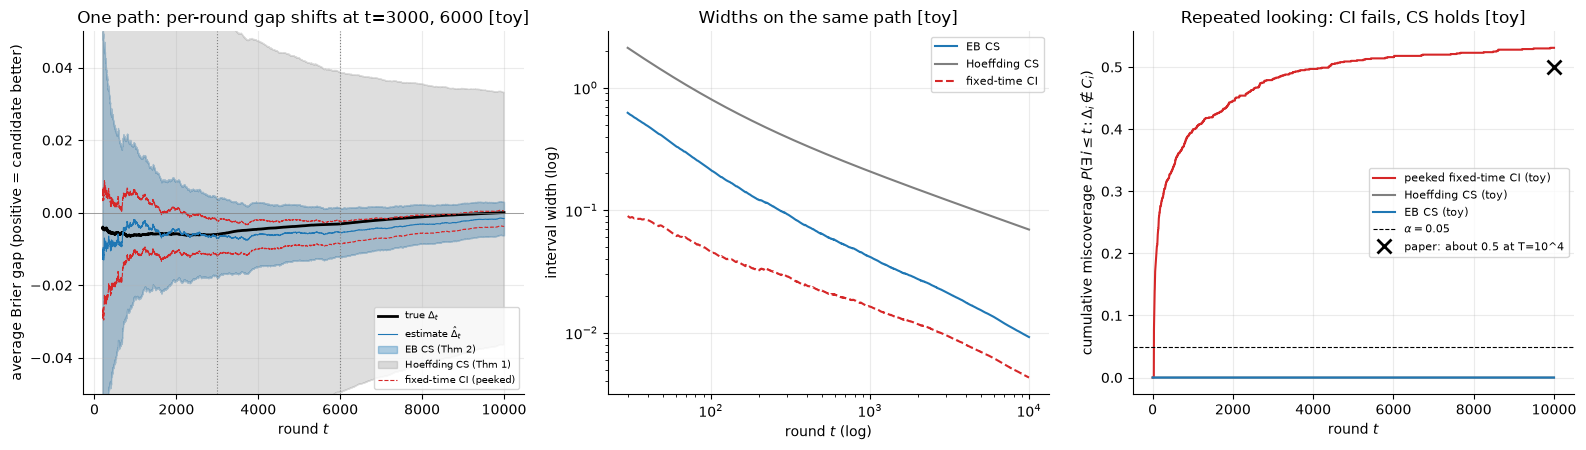

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
ex = example
x = np.arange(1, T2 + 1)
sl = slice(199, None)
ax[0].plot(x[sl], ex["Delta"][sl], color=PALETTE["truth"], lw=2, label=r"true $\Delta_t$")
ax[0].plot(x[sl], ex["Dhat"][sl], color=PALETTE["cr"], lw=0.8, label=r"estimate $\hat\Delta_t$")
ax[0].fill_between(x[sl], ex["lo"][sl], ex["up"][sl], color=PALETTE["cr"], alpha=0.35, label="EB CS (Thm 2)")
ax[0].fill_between(x[sl], (ex["Dhat"] - half_h)[sl], (ex["Dhat"] + half_h)[sl], color=PALETTE["hoeffding"], alpha=0.25, label="Hoeffding CS (Thm 1)")
ax[0].plot(x[sl], (ex["Dhat"] - ex["hw"])[sl], "--", color=PALETTE["peek"], lw=0.8, label="fixed-time CI (peeked)")
ax[0].plot(x[sl], (ex["Dhat"] + ex["hw"])[sl], "--", color=PALETTE["peek"], lw=0.8)
ax[0].axhline(0, color="grey", lw=0.5); ax[0].set_ylim(-0.05, 0.05)
for tc in (3000, 6000): ax[0].axvline(tc, color="grey", ls=":", lw=0.8)
ax[0].set_xlabel("round $t$"); ax[0].set_ylabel(r"average Brier gap (positive = candidate better)")
ax[0].set_title("One path: per-round gap shifts at t=3000, 6000 [toy]"); ax[0].legend(fontsize=7, loc="lower right")

ax[1].loglog(x[29:], (ex["up"] - ex["lo"])[29:], color=PALETTE["cr"], label="EB CS")
ax[1].loglog(x[29:], 2 * half_h[29:], color=PALETTE["hoeffding"], label="Hoeffding CS")
ax[1].loglog(x[29:], 2 * ex["hw"][29:], "--", color=PALETTE["peek"], label="fixed-time CI")
ax[1].set_xlabel("round $t$ (log)"); ax[1].set_ylabel("interval width (log)"); ax[1].set_title("Widths on the same path [toy]"); ax[1].legend(fontsize=8)

ax[2].plot(x, cum["peek"], color=PALETTE["peek"], label="peeked fixed-time CI (toy)")
ax[2].plot(x, cum["hoef"], color=PALETTE["hoeffding"], label="Hoeffding CS (toy)")
ax[2].plot(x, cum["eb"], color=PALETTE["cr"], label="EB CS (toy)")
ax[2].axhline(0.05, color=PALETTE["truth"], ls="--", lw=0.8, label=r"$\alpha=0.05$")
ax[2].plot([T2], [0.5], "x", color=PALETTE["truth"], ms=10, mew=2, label="paper: about 0.5 at T=10^4")
ax[2].set_xlabel("round $t$"); ax[2].set_ylabel(r"cumulative miscoverage $P(\exists\, i\leq t:\Delta_i\notin C_i)$")
ax[2].set_title("Repeated looking: CI fails, CS holds [toy]"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. PROVE, continued: weak null, strong null and e-processes (Choe and Ramdas)

**Two nulls (Sec. 4.4).** The **weak null** $H_0^w(p,q):\ \Delta_t=\frac1t\sum_{i\le t}\delta_i\le0$ for all $t$ (Eq. 18) says forecaster $p$ is not better *on average so far*; the **strong null** $H_0^s(p,q):\ \delta_t\le 0$ for all $t$ (Eq. 21) says $p$ is never better at any single round. The strong null is a much smaller set, so a test of it rejects far more easily, and that can mislead. The paper's Eq. 22 example (fix $k>2$, say $k=7$ for Sundays): $\delta_t=+0.1$ if $t=k,2k,3k,\dots$ and $\delta_t=-1$ otherwise. "Because the strong null is false, any (powerful) sequential test for the strong null will reject it, and yet this may be a confusing conclusion as $q$ is generally a better forecaster." Here the weak null is **true** (the average gap is about $(0.1-6)/7<0$), so a valid weak-null test must not reject. A betting signal that wins one day a week and loses badly the other six is exactly what a per-round test would flatter.

**e-process for the weak null (Thm 3, Eq. 24).** Under the conditions of Thm 2 ($|\hat\delta_i|\le c/2$, predictable $\gamma_i$), for each $\lambda\in[0,1/c)$
$$E_t(\lambda)=\exp\Big\{\lambda\sum_{i\le t}\hat\delta_i-\psi_{E,c}(\lambda)\hat V_t\Big\}$$
is an **e-process** for $H_0^w(p,q)$: a nonnegative process starting at 1 with $\mathbb{E}_P[E_\tau]\le1$ for every stopping time $\tau$ (Eq. 23), and so is any mixture $E_t^{\rm mix}=\int E_t(\lambda)\,dF(\lambda)$. The reason is one line (derived here from the paper's Eq. 40 argument): under $H_0^w$, $\sum_i\delta_i=t\Delta_t\le0$, hence $\lambda\sum\hat\delta_i\le\lambda\sum(\hat\delta_i-\delta_i)$ and $E_t(\lambda)$ is bounded by the test supermartingale $L_t(\lambda)=\exp\{\lambda S_t-\psi_{E,c}(\lambda)\hat V_t\}$. With the gamma density of Section 2 the mixture is exactly $E_t^{\rm mix}=m(\sum_i\hat\delta_i,\hat V_t)$ (Prop. 3), which is what `cr_log_eprocess` computes. An e-process converts to a **p-process** $p_t=1/\sup_{i\le t}E_i$ (Eq. 26), valid at any stopping time (Eq. 25).

**CS test and the stated duality (Cor. 1, Eq. 19).** Rejecting $H_0^w(p,q)$ when the CS lower bound $L_t>0$ (and $H_0^w(q,p)$ when $U_t<0$) is a level-$\alpha$ sequential test. The paper states that testing whether an e-process exceeds $2/\alpha$ "corresponds to a level-$(\alpha/2)$ sequential test equivalent to the one stated in Corollary 1", and that in its plots the CS excludes zero precisely when an e-process exceeds $2/\alpha$. **Why this is exact for the default construction (derived here):** the boundary is $u(v)=\sup\{s:m(s,v)<2/\alpha\}$ and $m(\cdot,v)$ is increasing, so $\sum\hat\delta_i>u(\hat V_t)\iff m(\sum\hat\delta_i,\hat V_t)>2/\alpha$, i.e. $L_t>0\iff E_t^{\rm mix}>2/\alpha$, *provided the CS and the e-process use the same $\rho$ and the same predictable $\gamma_i$*. We test this below, including a deliberately mismatched pair.

**Predictable subsequences (App. F.1, Eq. 96 to 102).** For a $\{0,1\}$-valued sequence $\xi_t$ that is *predictable* (fixed before round $t$), the target becomes $\Delta_t(\xi)=\sum_i\xi_i\delta_i/\sum_i\xi_i$ (Eq. 96), the supermartingale multiplies only over $i$ with $\xi_i=1$ (Eq. 97 to 100), and the e-process is $E_t(\lambda;\xi)=\prod_{i:\xi_i=1}\exp\{\lambda\hat\delta_i-\psi_E(\lambda)(\hat\delta_i-\gamma_i)^2\}$ (Eq. 101, with $E_t\le L_t$ by Eq. 102). In practice one applies the same CS and e-process to the sub-series $\hat\delta_i$, $\xi_i=1$. This is the only kind of "restart on a subset" the paper covers: the subset rule must be fixed in advance.

**Simulation design (derived here).** To control the truth exactly we simulate the differential sequence directly: $\hat\delta_t=\delta_t+0.5\,\epsilon_t$ with $\epsilon_t$ independent signs, so $\mathbb{E}_{t-1}\hat\delta_t=\delta_t$ and $|\hat\delta_t|\le1$ ($c=2$). Worlds: (W1) $\delta_t=0$ for all $t$ (boundary of the weak null); (W2) a **late rally**, $\delta_t=-0.1$ for the first half and $+0.1$ for the second half, so $\Delta_t\le0$ throughout with $\Delta_T=0$; (W3) $\delta_t=-0.05$ (deep inside the null); (W4) the Eq. 22 world with $k=7$, where on the $k$-th rounds $\hat\delta_t=0.1\pm0.3\epsilon_t$ and otherwise $\hat\delta_t=-1$ exactly. The event $\{\sup_tE_t^{\rm mix}\ge1/\alpha\}$ is evaluated at **every** $t$ through the monotone map above (the crossing $\sum\hat\delta_i\ge u_{1/\alpha}(\hat V_t;\rho)$ with the mixture's own $\rho$), and cross-checked against direct evaluation of the closed-form e-process on a thinned time grid.

In [10]:
def sim_delta_hat(rng, n_paths, delta_seq, noise=0.5):
    """Directly simulate delta_hat_t = delta_t + noise * eps_t (eps_t = +/-1 with prob 1/2): E_{t-1}[delta_hat_t] = delta_t exactly (derived here)."""
    eps = rng.integers(0, 2, size=(n_paths, len(delta_seq))) * 2.0 - 1.0
    return np.asarray(delta_seq, float)[None, :] + noise * eps


def intrinsic(delta_hat):
    """Running sum and intrinsic time V-hat_t = sum (delta_hat_i - Delta-hat_{i-1})^2 (the CS/e-process's own quantities)."""
    t = np.arange(1, delta_hat.shape[-1] + 1)
    s = np.cumsum(delta_hat, axis=-1)
    gam = np.concatenate([np.zeros(delta_hat.shape[:-1] + (1,)), (s / t)[..., :-1]], axis=-1)
    return s, np.cumsum((delta_hat - gam) ** 2, axis=-1)


def crossing(delta_hat, level, alpha_dual=0.05, v_opt=10.0):
    """Boolean array (..., T): E_t^mix >= level at every t, via the monotone map  sum(delta_hat) >= u_{1/level}(V-hat_t; rho),
    with rho the e-process's own tuning parameter (from alpha_dual/2, v_opt)."""
    s, v = intrinsic(delta_hat)
    rho_e = _cr_rho(alpha_dual / 2, v_opt)
    return s >= cr_uniform_boundary(v, alpha_side=1.0 / level, rho=rho_e)


ALPHA3 = 0.05
T3, N3 = 2000, 1000
half = T3 // 2
worlds = {
    "W1 boundary null (delta=0)":      np.zeros(T3),
    "W2 late rally (-0.1 then +0.1)":  np.where(np.arange(1, T3 + 1) <= half, -0.1, 0.1),
    "W3 deep null (delta=-0.05)":      np.full(T3, -0.05),
}
rng3 = np.random.default_rng(SEED + 3)
t_s3 = time.time()
res3 = {}
for name, dseq in worlds.items():
    dh = sim_delta_hat(rng3, N3, dseq)
    Delta_t = np.cumsum(dseq) / np.arange(1, T3 + 1)
    assert np.all(Delta_t <= 1e-12), "world must satisfy the weak null"
    p20 = crossing(dh, 1 / ALPHA3).any(axis=1).mean()          # P(sup_t E_t >= 1/alpha)
    p40 = crossing(dh, 2 / ALPHA3).any(axis=1).mean()          # P(sup_t E_t >= 2/alpha)
    # cross-check the boundary shortcut against the closed-form e-process on every 25th t
    sel = np.arange(24, T3, 25)
    le = cr_log_eprocess(dh[:400], alpha=ALPHA3)[:, sel]
    agree = np.mean((le >= np.log(1 / ALPHA3)) == crossing(dh[:400], 1 / ALPHA3)[:, sel])
    res3[name] = dict(p20=float(p20), p40=float(p40), agree=float(agree), maxlogE=float(np.max(le)))
    print(f"{name:34s} P(sup E>=1/alpha={1/ALPHA3:.0f})={p20:.4f}   P(sup E>=2/alpha={2/ALPHA3:.0f})={p40:.4f}   "
          f"boundary-shortcut vs closed form agreement={agree:.4f}")
print(f"(weak-null simulations took {time.time() - t_s3:.1f} s)")
se3 = mc_se(ALPHA3, N3)
check("3a", "weak null true: P(sup_t E_t^mix >= 1/alpha), worst of W1..W3 (1,000 paths x T=2000 each)",
      f"{max(r['p20'] for r in res3.values()):.4f}", f"<= alpha + 3 s.e. = {ALPHA3 + 3 * se3:.4f}", max(r['p20'] for r in res3.values()) <= ALPHA3 + 3 * se3)
check("3b", "same, at level 2/alpha (the CS-dual threshold, one-sided error alpha/2)", f"{max(r['p40'] for r in res3.values()):.4f}",
      f"<= alpha/2 + 3 s.e. = {ALPHA3 / 2 + 3 * mc_se(ALPHA3 / 2, N3):.4f}", max(r['p40'] for r in res3.values()) <= ALPHA3 / 2 + 3 * mc_se(ALPHA3 / 2, N3))
check("3c", "boundary shortcut for {E_t >= 1/alpha} agrees with the closed-form e-process at the checked t (min over worlds)",
      f"{min(r['agree'] for r in res3.values()):.4f}", ">= 0.999", min(r['agree'] for r in res3.values()) >= 0.999)

W1 boundary null (delta=0)         P(sup E>=1/alpha=20)=0.0010   P(sup E>=2/alpha=40)=0.0010   boundary-shortcut vs closed form agreement=1.0000


W2 late rally (-0.1 then +0.1)     P(sup E>=1/alpha=20)=0.0000   P(sup E>=2/alpha=40)=0.0000   boundary-shortcut vs closed form agreement=1.0000


W3 deep null (delta=-0.05)         P(sup E>=1/alpha=20)=0.0000   P(sup E>=2/alpha=40)=0.0000   boundary-shortcut vs closed form agreement=1.0000
(weak-null simulations took 0.8 s)
SELF-CHECK 3a: weak null true: P(sup_t E_t^mix >= 1/alpha), worst of W1..W3 (1,000 paths x T=2000 each) -> 0.0010 (threshold <= alpha + 3 s.e. = 0.0707) -> MET
SELF-CHECK 3b: same, at level 2/alpha (the CS-dual threshold, one-sided error alpha/2) -> 0.0010 (threshold <= alpha/2 + 3 s.e. = 0.0398) -> MET
SELF-CHECK 3c: boundary shortcut for {E_t >= 1/alpha} agrees with the closed-form e-process at the checked t (min over worlds) -> 1.0000 (threshold >= 0.999) -> MET


In [11]:
# (b) The Eq. 22 world: weak null TRUE, strong null FALSE (k = 7). T = 4200 gives 600 Sunday rounds: with the wide default mixture (rho about 98) the subsequence test needs several hundred rounds to have power.
K22, T22, N22 = 7, 4200, 500
t22 = np.arange(1, T22 + 1)
is_k = (t22 % K22 == 0)
delta22 = np.where(is_k, 0.1, -1.0)
rng4 = np.random.default_rng(SEED + 4)
eps = rng4.integers(0, 2, size=(N22, T22)) * 2.0 - 1.0
dh22 = np.where(is_k[None, :], 0.1 + 0.3 * eps, -1.0)             # E_{t-1} delta_hat_t = delta_t exactly
Delta22 = np.cumsum(delta22) / t22
print(f"Eq. 22 world: true Delta_t ranges in [{Delta22.min():.3f}, {Delta22.max():.3f}] (weak null true: Delta_t<=0 for all t: {bool(np.all(Delta22 <= 0))}); "
      f"strong null false on {int(is_k.sum())} of {T22} rounds (delta_t = +0.1)")

# Weak-null e-process on the FULL history (what Thm 3 tests).
rej_weak = crossing(dh22, 1 / ALPHA3).any(axis=1)
logE_full = cr_log_eprocess(dh22[:5], alpha=ALPHA3)                   # a few paths, for the chart
# Strong-null-style test: the predictable subsequence xi_t = 1{t mod 7 = 0}, Eq. 101 (rounds on which delta_t > 0)
dsub = dh22[:, is_k]
cross_sub = crossing(dsub, 1 / ALPHA3)
rej_sub = cross_sub.any(axis=1)
first_sub_round = np.where(rej_sub, t22[is_k][np.argmax(cross_sub, axis=1)], -1)
logE_sub = cr_log_eprocess(dsub[:5], alpha=ALPHA3)
p_final_weak = np.minimum(1.0, 1 / np.exp(np.maximum.accumulate(cr_log_eprocess(dh22[:200], alpha=ALPHA3), axis=1)[:, -1]))
print(f"weak-null e-process (full history): rejection fraction {rej_weak.mean():.3f}; final p-process 1/sup E (median of 200 paths) = {np.median(p_final_weak):.3f}")
print(f"strong-null-style subsequence e-process (Sundays only): rejection fraction {rej_sub.mean():.3f}; median round of first crossing {np.median(first_sub_round[rej_sub]):.0f}")
check("3d", "Eq. 22 world: the weak-null e-process does NOT reject (fraction of 500 paths that ever reach 1/alpha)", f"{rej_weak.mean():.3f}",
      f"<= alpha + 3 s.e. = {ALPHA3 + 3 * mc_se(ALPHA3, N22):.3f}", rej_weak.mean() <= ALPHA3 + 3 * mc_se(ALPHA3, N22))
check("3e", "Eq. 22 world: a strong-null-style test on the predictable 7th-round subsequence DOES reject (fraction of paths)", f"{rej_sub.mean():.3f}", ">= 0.95", rej_sub.mean() >= 0.95)

Eq. 22 world: true Delta_t ranges in [-1.000, -0.843] (weak null true: Delta_t<=0 for all t: True); strong null false on 600 of 4200 rounds (delta_t = +0.1)


weak-null e-process (full history): rejection fraction 0.000; final p-process 1/sup E (median of 200 paths) = 1.000
strong-null-style subsequence e-process (Sundays only): rejection fraction 1.000; median round of first crossing 1274
SELF-CHECK 3d: Eq. 22 world: the weak-null e-process does NOT reject (fraction of 500 paths that ever reach 1/alpha) -> 0.000 (threshold <= alpha + 3 s.e. = 0.079) -> MET
SELF-CHECK 3e: Eq. 22 world: a strong-null-style test on the predictable 7th-round subsequence DOES reject (fraction of paths) -> 1.000 (threshold >= 0.95) -> MET


In [12]:
# (c) Duality: {CS lower bound > 0} versus {E_t^mix >= 2/alpha}, checked on every 4th round (closed-form e-process is the slow part).
T5, N5, STEP = 2000, 400, 4
sel5 = np.arange(STEP - 1, T5, STEP)
rng5 = np.random.default_rng(SEED + 5)
dual = {}
for name, g in [("gap +0.02", 0.02), ("gap 0", 0.0), ("gap -0.02", -0.02), ("gap +0.05", 0.05)]:
    dh = sim_delta_hat(rng5, N5, np.full(T5, g))
    lo, up = cr_confseq(dh, ALPHA3)
    A = (lo > 0)[:, sel5]
    logE = cr_log_eprocess(dh, alpha=ALPHA3)[:, sel5]                      # same alpha, v_opt, gamma as the CS
    B = logE >= np.log(2 / ALPHA3)
    logE_mis = cr_log_eprocess(dh, alpha=ALPHA3, v_opt=100.0)[:, sel5]      # deliberately mismatched mixture (v_opt 100 vs 10)
    Bm = logE_mis >= np.log(2 / ALPHA3)
    dual[name] = dict(agree=float(np.mean(A == B)), paths_all=float(np.mean(np.all(A == B, axis=1))), n_mismatch=int(np.sum(A != B)),
                      frac_excl=float(A.mean()), agree_mis=float(np.mean(A == Bm)), n_mis=int(np.sum(A != Bm)),
                      first_cs=float(np.mean(np.where(A.any(1), np.argmax(A, 1), -1)[A.any(1)])) if A.any() else float("nan"))
    if g == 0.05:
        ex_dual = dict(lo=lo[0], logE=cr_log_eprocess(dh[:1], alpha=ALPHA3)[0], dh=dh[0])
    d = dual[name]
    print(f"{name:10s}: CS-excludes-0 on {d['frac_excl']:.3f} of (path, t) pairs; agreement with E>=2/alpha {d['agree']:.6f} "
          f"({d['n_mismatch']} mismatches of {A.size}); all-t agreement on {d['paths_all']:.3f} of paths | mismatched mixture (v_opt=100): "
          f"agreement {d['agree_mis']:.4f} ({d['n_mis']} mismatches)")
tot_mis = sum(v["n_mismatch"] for v in dual.values())
check("3f", "duality (same rho, same gamma_i): fraction of (path, t) pairs where 'CS lower bound > 0' and 'E_t >= 2/alpha' agree, min over gaps",
      f"{min(v['agree'] for v in dual.values()):.6f} ({tot_mis} mismatches in total)", "== 1.0 (exact equivalence derived above)", tot_mis == 0)
check("3g", "with a DIFFERENT mixture (v_opt=100 in the e-process, 10 in the CS) the equivalence breaks: mismatches exist", f"{sum(v['n_mis'] for v in dual.values())}",
      "> 0 (the duality is a property of the matched pair, not of any pair)", sum(v['n_mis'] for v in dual.values()) > 0)

# (d) Predictable subsequence: xi_t = 1{t > t0}, gap changes at t0.
T6, N6, T0 = 4000, 500, 2000
dseq6 = np.where(np.arange(1, T6 + 1) <= T0, -0.1, 0.1)
rng6 = np.random.default_rng(SEED + 6)
dh6 = sim_delta_hat(rng6, N6, dseq6)
t6 = np.arange(1, T6 + 1)
Delta_full = np.cumsum(dseq6) / t6                                        # Delta_t of the full history
n_sub = np.arange(1, T6 - T0 + 1)
Delta_sub = np.cumsum(dseq6[T0:]) / n_sub                                  # Delta_t(xi) for t > t0  (Eq. 96), = +0.1
lo_f, up_f = cr_confseq(dh6, ALPHA3)                                       # full-history CS
lo_s, up_s = cr_confseq(dh6[:, T0:], ALPHA3)                               # CS on the subsequence xi_t = 1{t > t0}
miss_full = ((Delta_full < lo_f) | (Delta_full > up_f)).any(axis=1).mean()
miss_sub = ((Delta_sub < lo_s) | (Delta_sub > up_s)).any(axis=1).mean()
full_covers_sub_target = ((lo_f[:, -1] <= 0.1) & (0.1 <= up_f[:, -1])).mean()
sub_excl0 = (lo_s[:, -1] > 0).mean()
full_excl0 = (lo_f[:, -1] > 0).mean()
print(f"gap -0.1 for t<=2000, +0.1 after; at T=4000: full-history Delta_T = {Delta_full[-1]:.3f}, subsequence Delta_T(xi) = {Delta_sub[-1]:.3f}")
print(f"full-history CS: whole-horizon miscoverage of Delta_t = {miss_full:.3f}; contains Delta_T(xi)=0.1 at T in {full_covers_sub_target:.3f} of paths; "
      f"lower bound > 0 in {full_excl0:.3f}")
print(f"subsequence CS: whole-horizon miscoverage of Delta_t(xi) = {miss_sub:.3f}; lower bound > 0 at T in {sub_excl0:.3f} of paths")
ex6 = dict(lo_f=lo_f[0], up_f=up_f[0], lo_s=lo_s[0], up_s=up_s[0])
check("3h", "subsequence CS (xi_t = 1{t>t0}, fixed in advance) covers Delta_t(xi) for all t>t0: whole-horizon miscoverage", f"{miss_sub:.3f}",
      f"<= alpha + 3 s.e. = {ALPHA3 + 3 * mc_se(ALPHA3, N6):.3f}", miss_sub <= ALPHA3 + 3 * mc_se(ALPHA3, N6))
check("3i", "the full-history CS also covers its own target Delta_t (whole-horizon miscoverage)", f"{miss_full:.3f}",
      f"<= {ALPHA3 + 3 * mc_se(ALPHA3, N6):.3f}", miss_full <= ALPHA3 + 3 * mc_se(ALPHA3, N6))
check("3j", "the two CSs answer different questions: at T the full-history CS excludes the subsequence target 0.1 in most paths, the subsequence CS excludes 0",
      f"full CS contains 0.1 in {full_covers_sub_target:.3f}; subsequence CS lower>0 in {sub_excl0:.3f}", "full CS contains 0.1 in <= 0.05 of paths and subsequence lower>0 in >= 0.95",
      full_covers_sub_target <= 0.05 and sub_excl0 >= 0.95)

gap +0.02 : CS-excludes-0 on 0.004 of (path, t) pairs; agreement with E>=2/alpha 1.000000 (0 mismatches of 200000); all-t agreement on 1.000 of paths | mismatched mixture (v_opt=100): agreement 0.9882 (2361 mismatches)


gap 0     : CS-excludes-0 on 0.000 of (path, t) pairs; agreement with E>=2/alpha 1.000000 (0 mismatches of 200000); all-t agreement on 1.000 of paths | mismatched mixture (v_opt=100): agreement 1.0000 (2 mismatches)


gap -0.02 : CS-excludes-0 on 0.000 of (path, t) pairs; agreement with E>=2/alpha 1.000000 (0 mismatches of 200000); all-t agreement on 1.000 of paths | mismatched mixture (v_opt=100): agreement 1.0000 (0 mismatches)


gap +0.05 : CS-excludes-0 on 0.237 of (path, t) pairs; agreement with E>=2/alpha 1.000000 (0 mismatches of 200000); all-t agreement on 1.000 of paths | mismatched mixture (v_opt=100): agreement 0.8780 (24402 mismatches)
SELF-CHECK 3f: duality (same rho, same gamma_i): fraction of (path, t) pairs where 'CS lower bound > 0' and 'E_t >= 2/alpha' agree, min over gaps -> 1.000000 (0 mismatches in total) (threshold == 1.0 (exact equivalence derived above)) -> MET
SELF-CHECK 3g: with a DIFFERENT mixture (v_opt=100 in the e-process, 10 in the CS) the equivalence breaks: mismatches exist -> 26765 (threshold > 0 (the duality is a property of the matched pair, not of any pair)) -> MET
gap -0.1 for t<=2000, +0.1 after; at T=4000: full-history Delta_T = -0.000, subsequence Delta_T(xi) = 0.100
full-history CS: whole-horizon miscoverage of Delta_t = 0.000; contains Delta_T(xi)=0.1 at T in 0.000 of paths; lower bound > 0 in 0.000
subsequence CS: whole-horizon miscoverage of Delta_t(xi) = 0.000; lower 

**How to read this chart**

Left panel (Eq. 22 world, five paths each): x is the round; y is $\log_{10}E_t$. The blue curves are the **weak-null** e-process on the full history: they stay far below the red $1/\alpha=20$ line, correctly refusing to reject because the forecaster is generally worse than the market. The orange curves are the e-process on the predictable "every 7th round" subsequence (plotted against the original round number): they climb through $1/\alpha$, the "strong-null-style" verdict that "the candidate is sometimes better". Both are valid answers to *different* nulls; the project point is that a per-round or per-subset test can flatter a signal that loses on average, so the headline proof of an edge must be the weak-null test on the full history. Middle panel (one path with a true gap of +0.05): the CS lower bound (blue, left axis) becomes positive at exactly the round where $\log_{10}E_t^{\rm mix}$ (green, right axis) crosses $\log_{10}(2/\alpha)$ (dashed): the duality. Right panel (one path, gap $-0.1$ then $+0.1$ from $t_0=2000$): the full-history CS (blue) hovers around the average gap, which returns to 0, while the CS on the pre-specified subsequence $t>t_0$ (orange, drawn against original round numbers) tracks the new gap $+0.1$ and excludes 0. The subsequence rule was fixed in advance; choosing $t_0$ after looking at the data would change the tested hypothesis and is **not** covered by App. F.1.

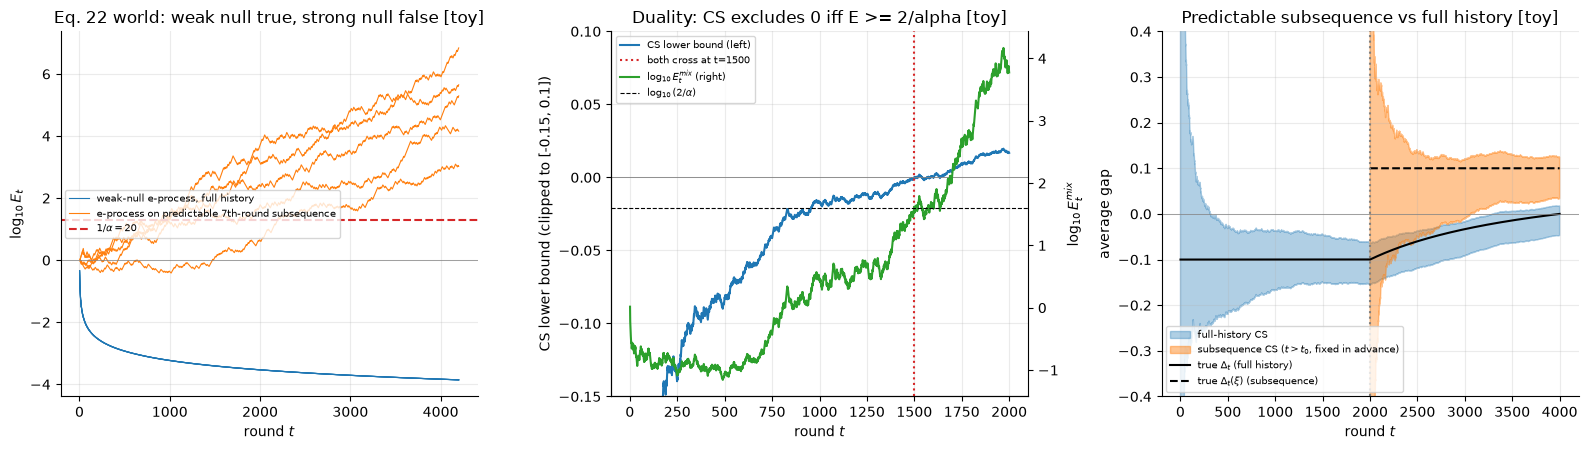

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
tx = np.arange(1, T22 + 1); tsub = t22[is_k]
for i in range(5):
    ax[0].plot(tx, logE_full[i] / np.log(10), color=PALETTE["cr"], lw=0.8, label="weak-null e-process, full history" if i == 0 else None)
    ax[0].plot(tsub, logE_sub[i] / np.log(10), color=PALETTE["elond"], lw=0.8, label="e-process on predictable 7th-round subsequence" if i == 0 else None)
ax[0].axhline(np.log10(1 / ALPHA3), color=PALETTE["peek"], ls="--", label=r"$1/\alpha=20$")
ax[0].axhline(0, color="grey", lw=0.5)
ax[0].set_xlabel("round $t$"); ax[0].set_ylabel(r"$\log_{10}E_t$"); ax[0].set_title("Eq. 22 world: weak null true, strong null false [toy]")
ax[0].legend(fontsize=7, loc="center left")

tt5 = np.arange(1, T5 + 1)
a1 = ax[1]; a2 = a1.twinx()
a1.plot(tt5, ex_dual["lo"], color=PALETTE["cr"], label="CS lower bound (left)")
a1.axhline(0, color="grey", lw=0.6)
a2.plot(tt5, ex_dual["logE"] / np.log(10), color=PALETTE["calib"], label=r"$\log_{10}E_t^{mix}$ (right)")
a2.axhline(np.log10(2 / ALPHA3), color=PALETTE["truth"], ls="--", lw=0.8, label=r"$\log_{10}(2/\alpha)$")
cross_cs = int(np.argmax(ex_dual["lo"] > 0)) + 1
a1.axvline(cross_cs, color=PALETTE["peek"], ls=":", label=f"both cross at t={cross_cs}")
a1.set_ylim(-0.15, 0.1); a1.set_xlabel("round $t$"); a1.set_ylabel("CS lower bound (clipped to [-0.15, 0.1])"); a2.set_ylabel(r"$\log_{10}E_t^{mix}$")
a1.set_title("Duality: CS excludes 0 iff E >= 2/alpha [toy]")
h1, l1 = a1.get_legend_handles_labels(); h2, l2 = a2.get_legend_handles_labels(); a1.legend(h1 + h2, l1 + l2, fontsize=7, loc="upper left")
a2.grid(False); a2.spines["right"].set_visible(True)

t6x = np.arange(1, T6 + 1)
ax[2].fill_between(t6x, ex6["lo_f"], ex6["up_f"], color=PALETTE["cr"], alpha=0.35, label="full-history CS")
ax[2].fill_between(t6x[T0:], ex6["lo_s"], ex6["up_s"], color=PALETTE["elond"], alpha=0.45, label=r"subsequence CS ($t>t_0$, fixed in advance)")
ax[2].plot(t6x, Delta_full, color=PALETTE["truth"], lw=1.5, label=r"true $\Delta_t$ (full history)")
ax[2].plot(t6x[T0:], Delta_sub, color=PALETTE["truth"], lw=1.5, ls="--", label=r"true $\Delta_t(\xi)$ (subsequence)")
ax[2].axhline(0, color="grey", lw=0.5); ax[2].axvline(T0, color="grey", ls=":")
ax[2].set_ylim(-0.4, 0.4); ax[2].set_xlabel("round $t$"); ax[2].set_ylabel("average gap")
ax[2].set_title("Predictable subsequence vs full history [toy]"); ax[2].legend(fontsize=7, loc="lower left")
plt.tight_layout(); plt.show()

## 4. SCREEN: online FDR control with e-LOND (Xu and Ramdas)

**Setup (Sec. 1, Eq. 1 to 3).** Hypotheses $H_1,H_2,\dots$ arrive one at a time, each with an **e-value** $E_t\ge0$ satisfying $\mathbb{E}[E_t]\le1$ when $H_t$ is null (Eq. 3; a p-value satisfies $P(P_t\le s)\le s$, Eq. 2). An online procedure picks levels $\alpha_t$ and discovers $R_t=\{i\le t:E_i\ge1/\alpha_i\}$. The goal is $\mathrm{FDR}(R_t)=\mathbb{E}\big[\tfrac{|R_t\cap H_0|}{|R_t|\vee1}\big]\le\alpha$ **for every $t$** (Eq. 1). A **discount sequence** $(\gamma_t)$ is nonnegative with $\sum_t\gamma_t\le1$; the paper's simulations use $\gamma_t=\frac1{t(t+1)}$ (App. B), which is what we use.

**Prior work (Sec. 3.1).** LOND uses levels $\alpha_t^{\rm LOND}=\alpha\gamma_t(|R_{t-1}|+1)$ and needs independent or PRDS p-values (Fact 1). Under **arbitrary** dependence one must use r-LOND, with levels $\alpha\gamma_t\,\beta_t(|R_{t-1}|+1)$ (Eq. 5) for a reshaping function $\beta_t$ (Fact 2); the Benjamini-Yekutieli choice is $\beta_t^{\rm BY}(r)=(\lfloor r\rfloor\wedge t)/\ell_t$ with $\ell_t=\sum_{i\le t}1/i$. (The paper prints $(\lfloor r\rfloor\wedge t)$, a minimum with $t$; we implement exactly that.) Reshaping costs a factor $\ell_t\approx\ln t$ in level.

**e-LOND (Sec. 3.2, Thm 1).** Use the *un-reshaped* LOND levels on e-values: $\alpha_t^{\text{e-LOND}}=\alpha\gamma_t(|R_{t-1}|+1)$, discovering $H_t$ when $E_t\ge1/\alpha_t$.

> **Theorem 1.** "Under arbitrary dependence on e-values (3), $\mathrm{FDR}(R_t^{\text{e-LOND}})\le\alpha$ for each $t\in\mathbb{N}$. In addition, e-LOND strictly dominates r-LOND applied to $(1/E_t)$ for any sequence of reshaping functions $(\beta_t)$."

**Why it works: proof steps (Sec. 8.1), in one line each.** Write $\alpha_i$ for the e-LOND level. The key inequality is Eq. 6, $\mathbf 1\{E\ge\alpha^{-1}\}\le\alpha E$. (i) For a null $i$, a discovery at $i$ forces $|R_t|\ge|R_{i-1}|+1$, so $\mathrm{FDP}$'s null contribution is at most $\frac{\alpha_iE_i}{|R_t|\vee1}\mathbf 1\{|R_t|\ge|R_{i-1}|+1\}$. (ii) Substitute $\alpha_i=\alpha\gamma_i(|R_{i-1}|+1)$ and cancel $|R_{i-1}|+1$ with the lower bound on $|R_t|$. (iii) Drop the indicator. (iv) What remains is $\alpha\sum_{i\in H_0}\gamma_i\mathbb{E}[E_i]\le\alpha$, using only the *marginal* bound $\mathbb{E}[E_i]\le1$. No joint law of the $E_i$ was used, which is why any dependence is allowed (data reuse, overlapping games, shared latent factors).

**Dominance (derived here from the paper's statement).** $\beta_t^{\rm BY}(r)\le r$, so the r-LOND level with $p_t=1/E_t$ never exceeds the e-LOND level given the same number of past discoveries; by induction $R_t^{\text{r-LOND}}\subseteq R_t^{\text{e-LOND}}$ on **every** draw. We check that directly below, and we also count how often it is *strict*.

**Sharpness (App. C, Thm 6).** With $\sum\gamma_t=1$ there is a joint law of e-values whose FDR gets within $\varepsilon$ of $\alpha$. The construction: all hypotheses null; $\xi_t=\{E_t=(\alpha\gamma_t)^{-1}\text{ and }E_i=0\ \forall i\ne t\}$ with $P(\xi_t)=\alpha\gamma_t$, and $\xi_0=\{E_t=0\ \forall t\}$ with $P(\xi_0)=1-\alpha$. Then $\mathbb{E}[E_t]=1$ (valid e-values), the events are disjoint, and $\mathrm{FDR}(R_t)=\alpha\sum_{i\le t}\gamma_i$ (Eq. 22 of that appendix). So the e-LOND guarantee cannot be improved without extra assumptions; it is perfectly dependent (mutually exclusive) by construction.

**Simulation plan.** (Paper numbers, quoted only, not reproduced: the local-dependence experiment of Sec. 5.1 uses $T=1000$ hypotheses, $N=200$ samples each, $\mu_0=0$, $\mu_1\in\{2.5,3\}$, $\alpha=0.3$, 500 trials, Gaussian-copula covariance $\Sigma_{ij}=0.5^{|i-j|}$ for $|i-j|\le L$ and 0 otherwise. Our design is **derived here** and differs: the paper builds Hoeffding-type e-processes from 200 raw samples per hypothesis; we give each hypothesis one Gaussian z-statistic $z_t=\mu_t+\varepsilon_t$ and the likelihood-ratio e-value $E_t=\exp\{\lambda_tz_t-\lambda_t^2/2\}$ with $\lambda_t=\sqrt{2\ln(1/(\alpha\gamma_t))}$, which has $\mathbb{E}[E_t]=1$ under $\mu_t=0$ whatever the correlation of the $\varepsilon_t$'s. The paper's text also lists a crossover at $L\ge150$ for $\mu_1=2$ while its simulation lists $\mu_1\in\{2.5,3\}$; we quote it as stated and note the mismatch, and we do not test it.) We use $T=1000$ hypotheses in a **fixed order**, 500 trials, non-null fraction 20% at random positions, and three dependence structures: independent, banded Gaussian dependence (correlation $0.5^{|i-j|}$ up to lag $L=50$, a valid correlation matrix, checked numerically; derived here), and a perfectly dependent case ($\varepsilon_t\equiv\varepsilon$). The two functions `elond` and `rlond` are exported.

In [14]:
# EXPORT: elond
import numpy as np


def elond(e, alpha=0.1, gamma=None):
    """e-LOND (Xu and Ramdas, Sec. 3.2): level alpha_t = alpha * gamma_t * (|R_{t-1}| + 1); discover H_t when E_t >= 1/alpha_t.
    e has shape (..., K) with the K hypotheses in a FIXED order along the last axis; leading axes are independent
    replications, processed in a vectorised way. Default gamma_t = 1/(t(t+1)) (App. B of the paper).
    Returns (discovered bool array (..., K), levels array (..., K))."""
    e = np.asarray(e, dtype=float)
    K = e.shape[-1]
    if gamma is None:
        tt = np.arange(1, K + 1, dtype=float)
        gamma = 1.0 / (tt * (tt + 1.0))
    gamma = np.asarray(gamma, dtype=float)
    n_disc = np.zeros(e.shape[:-1])
    disc = np.zeros(e.shape, dtype=bool)
    levels = np.empty(e.shape)
    for t in range(K):
        a = alpha * gamma[t] * (n_disc + 1.0)
        levels[..., t] = a
        d = e[..., t] * a >= 1.0 - 1e-12            # tiny tolerance for floating-point ties (E exactly at 1/level)
        disc[..., t] = d
        n_disc = n_disc + d
    return disc, levels

In [15]:
# EXPORT: rlond
import numpy as np


def rlond(p, alpha=0.1, gamma=None):
    """r-LOND with the Benjamini-Yekutieli reshaping beta_t(r) = (floor(r) ^ t) / ell_t, ell_t = sum_{i<=t} 1/i
    (Eq. 5 of Xu and Ramdas; 'floor(r) ^ t' means min(floor(r), t)): level alpha * gamma_t * beta_t(|R_{t-1}| + 1),
    discover H_t when p_t <= level. Valid under arbitrary dependence of the p-values (Fact 2).
    p has shape (..., K), hypotheses in a FIXED order along the last axis. Returns discovered bool array (..., K)."""
    p = np.asarray(p, dtype=float)
    K = p.shape[-1]
    tt = np.arange(1, K + 1, dtype=float)
    if gamma is None:
        gamma = 1.0 / (tt * (tt + 1.0))
    gamma = np.asarray(gamma, dtype=float)
    ell = np.cumsum(1.0 / tt)
    n_disc = np.zeros(p.shape[:-1])
    disc = np.zeros(p.shape, dtype=bool)
    for t in range(K):
        beta = np.minimum(np.floor(n_disc + 1.0), tt[t]) / ell[t]
        d = p[..., t] <= alpha * gamma[t] * beta * (1.0 + 1e-12)   # tiny tolerance for floating-point ties
        disc[..., t] = d
        n_disc = n_disc + d
    return disc

In [16]:
# Tiny-case tests of elond / rlond (not an export cell).
tt_ = np.arange(1, 9, dtype=float)
g8 = 1 / (tt_ * (tt_ + 1))
e_toy = np.array([[0.0, 0.0, 1 / (0.1 * g8[2] * 1), 0.0, 0.0, 0.0, 0.0, 0.0]])            # exactly at the level of hypothesis 3
d_toy, l_toy = elond(e_toy, alpha=0.1)
check("4a", "elond: an e-value exactly at 1/level is a discovery, and the discovery lifts later levels by (|R|+1)",
      f"discovered index {np.where(d_toy[0])[0].tolist()}, level_4/(alpha*gamma_4) = {l_toy[0, 3] / (0.1 * g8[3]):.1f}", "[2] and 2.0",
      d_toy[0].tolist() == [False, False, True, False, False, False, False, False] and abs(l_toy[0, 3] / (0.1 * g8[3]) - 2.0) < 1e-12)
d2, l2 = elond(np.stack([e_toy[0], e_toy[0]]))
check("4b", "elond is vectorised over leading axes (2 identical replications give identical results, shapes preserved)",
      f"{d2.shape}, {l2.shape}, equal={bool(np.array_equal(d2[0], d2[1]))}", "(2, 8), (2, 8), True", d2.shape == (2, 8) and np.array_equal(d2[0], d2[1]))
# r-LOND on p = 1/E discovers nothing here (BY reshaping shrinks the level), while e-LOND does:
p_toy = np.where(e_toy > 0, 1 / np.maximum(e_toy, 1e-300), 1.0)
check("4c", "rlond on p=1/E at the same borderline point does not discover, e-LOND does (BY reshaping shrinks the level)",
      f"rlond {int(rlond(p_toy, alpha=0.1).sum())} discoveries, elond {int(d_toy.sum())}", "0 and 1", int(rlond(p_toy, alpha=0.1).sum()) == 0 and int(d_toy.sum()) == 1)

SELF-CHECK 4a: elond: an e-value exactly at 1/level is a discovery, and the discovery lifts later levels by (|R|+1) -> discovered index [2], level_4/(alpha*gamma_4) = 2.0 (threshold [2] and 2.0) -> MET
SELF-CHECK 4b: elond is vectorised over leading axes (2 identical replications give identical results, shapes preserved) -> (2, 8), (2, 8), equal=True (threshold (2, 8), (2, 8), True) -> MET
SELF-CHECK 4c: rlond on p=1/E at the same borderline point does not discover, e-LOND does (BY reshaping shrinks the level) -> rlond 0 discoveries, elond 1 (threshold 0 and 1) -> MET


In [17]:
T4, TRIALS4, PI1, L4 = 1000, 500, 0.2, 50
tt4 = np.arange(1, T4 + 1, dtype=float)
gam4 = 1.0 / (tt4 * (tt4 + 1.0))


def banded_chol(T, L, rho=0.5):
    """Cholesky factor of a banded correlation matrix Sigma_ij = rho^|i-j| for |i-j|<=L else 0, projected to the nearest
    PSD matrix (eigenvalues clipped) and re-normalised to unit diagonal (derived here; the truncated matrix need not be PSD)."""
    i = np.arange(T)
    D = np.abs(i[:, None] - i[None, :])
    Sg = np.where(D <= L, rho ** D, 0.0)
    w, V = np.linalg.eigh(Sg)
    min_eig = float(w.min())
    Sg = (V * np.clip(w, 1e-8, None)) @ V.T
    dg = np.sqrt(np.diag(Sg)); Sg = Sg / dg[:, None] / dg[None, :]
    return np.linalg.cholesky(Sg + 1e-10 * np.eye(T)), min_eig


CH_BAND, min_eig_band = banded_chol(T4, L4)


def gen_z(rng, n, mu, dep):
    """Standard-normal noise with the requested dependence, plus the mean vector mu (shape (n, T))."""
    g = rng.standard_normal((n, T4))
    if dep == "independent": eps = g
    elif dep == "banded": eps = g @ CH_BAND.T
    elif dep == "perfect": eps = np.repeat(g[:, :1], T4, axis=1)
    return mu + eps


def to_e(z, alpha):
    lam = np.sqrt(2.0 * np.log(1.0 / (alpha * gam4)))        # lambda_t = sqrt(2 ln(1/(alpha gamma_t)))
    return np.exp(lam * z - lam ** 2 / 2.0)


def run_case(seed, alpha, mu1, dep):
    rng = np.random.default_rng(seed)
    nonnull = rng.random((TRIALS4, T4)) < PI1                 # non-nulls at random positions (a fixed order is used for testing)
    mu = np.where(nonnull, mu1, 0.0)
    z = gen_z(rng, TRIALS4, mu, dep)
    E = to_e(z, alpha)
    de, _ = elond(E, alpha)
    dr = rlond(np.minimum(1.0, 1.0 / np.maximum(E, 1e-300)), alpha)
    out = {}
    for name, d in [("elond", de), ("rlond", dr)]:
        false_cum = np.cumsum(d & ~nonnull, axis=1); tot_cum = np.cumsum(d, axis=1)
        fdp = false_cum / np.maximum(tot_cum, 1)
        out[name] = dict(fdr_t=fdp.mean(axis=0), fdr=float(fdp[:, -1].mean()),
                         power=float((d & nonnull).sum() / max(nonnull.sum(), 1)), n_disc=tot_cum[:, -1])
    out["superset_all"] = bool(np.all(de | ~dr))                 # every r-LOND discovery is an e-LOND discovery, on every draw
    out["strict_frac"] = float(np.mean((de & ~dr).any(axis=1)))
    out["extra_mean"] = float((de.sum(axis=1) - dr.sum(axis=1)).mean())
    return out

t_s4 = time.time()
ALPHAS4, MUS4, DEPS4 = [0.1, 0.3], [3.0, 4.0], ["independent", "banded", "perfect"]
res4 = {}
for ia, a in enumerate(ALPHAS4):
    for im, m in enumerate(MUS4):
        for idp, dp in enumerate(DEPS4):
            res4[(a, m, dp)] = run_case(SEED + 400 + 100 * ia + 10 * im + idp, a, m, dp)
print(f"(banded correlation matrix: smallest eigenvalue before projection {min_eig_band:.4f}; e-LOND/r-LOND simulations took {time.time() - t_s4:.1f} s)")
print("\nTOY numbers (our simulator; T=1000 hypotheses, 500 trials each, 20% non-null, mu_1 in z units):")
print(f"{'alpha':>5} {'mu1':>4} {'dependence':>12} {'FDR e-LOND':>11} {'FDR r-LOND':>11} {'power e-LOND':>13} {'power r-LOND':>13} {'superset':>9} {'strictly more (frac draws)':>27}")
for (a, m, dp), r in res4.items():
    print(f"{a:5.1f} {m:4.1f} {dp:>12} {r['elond']['fdr']:11.4f} {r['rlond']['fdr']:11.4f} {r['elond']['power']:13.3f} {r['rlond']['power']:13.3f} "
          f"{str(r['superset_all']):>9} {r['strict_frac']:27.3f}")
print("PAPER numbers (quoted, not reproduced): T=1000, N=200, mu_0=0, mu_1 in {2.5, 3}, alpha=0.3, 500 trials, Sigma_ij=0.5^|i-j| for |i-j|<=L (Sec. 5.1)")

for a in ALPHAS4:
    worst = max(max(r["elond"]["fdr_t"].max() for (aa, m, dp), r in res4.items() if aa == a and dp == d) for d in DEPS4)
    se = mc_se(a * 0.2, TRIALS4)
    check(f"4d[alpha={a}]", f"e-LOND FDR <= alpha at EVERY t (max over t, mu_1 and all three dependence structures), alpha={a}", f"{worst:.4f}",
          f"<= alpha + 3 s.e. = {a + 3 * mc_se(a, TRIALS4):.4f}", worst <= a + 3 * mc_se(a, TRIALS4))
check("4e", "e-LOND discovery set contains the r-LOND(1/E) discovery set on EVERY draw (all 12 cases x 500 draws)",
      f"{sum(r['superset_all'] for r in res4.values())}/{len(res4)} cases", "12/12", all(r["superset_all"] for r in res4.values()))
check("4f", "e-LOND is strictly more powerful than r-LOND in the independent/banded cases at mu_1=3, alpha=0.1 (power difference)",
      f"{res4[(0.1, 3.0, 'independent')]['elond']['power'] - res4[(0.1, 3.0, 'independent')]['rlond']['power']:.3f}, "
      f"{res4[(0.1, 3.0, 'banded')]['elond']['power'] - res4[(0.1, 3.0, 'banded')]['rlond']['power']:.3f}", "> 0 in both",
      all(res4[(0.1, 3.0, d)]['elond']['power'] > res4[(0.1, 3.0, d)]['rlond']['power'] for d in ["independent", "banded"]))

(banded correlation matrix: smallest eigenvalue before projection 0.3333; e-LOND/r-LOND simulations took 0.4 s)

TOY numbers (our simulator; T=1000 hypotheses, 500 trials each, 20% non-null, mu_1 in z units):
alpha  mu1   dependence  FDR e-LOND  FDR r-LOND  power e-LOND  power r-LOND  superset  strictly more (frac draws)
  0.1  3.0  independent      0.0021      0.0037         0.032         0.014      True                       0.926
  0.1  3.0       banded      0.0009      0.0012         0.034         0.014      True                       0.924
  0.1  3.0      perfect      0.0001      0.0000         0.077         0.047      True                       0.328
  0.1  4.0  independent      0.0001      0.0001         0.248         0.137      True                       1.000
  0.1  4.0       banded      0.0003      0.0004         0.248         0.138      True                       1.000
  0.1  4.0      perfect      0.0001      0.0000         0.293         0.190      True                      

In [18]:
# (iii) The sharpness construction of App. C, Thm 6 (perfectly dependent, mutually exclusive e-values, all null).
TRIALS_SH = 5000
res_sh = {}
for a in [0.1, 0.3]:
    rng = np.random.default_rng(SEED + 450 + int(a * 10))
    u = rng.random(TRIALS_SH)
    edges = np.concatenate([[0.0], np.cumsum(a * gam4)])          # xi_t has probability alpha*gamma_t, xi_0 the rest
    idx = np.searchsorted(edges, u, side="right") - 1            # idx in 0..T-1: event xi_{idx+1}; idx = T-1 last; beyond -> xi_0
    which = np.where(u < edges[-1], idx, -1)
    E_sh = np.zeros((TRIALS_SH, T4))
    hit = which >= 0
    E_sh[np.where(hit)[0], which[hit]] = 1.0 / (a * gam4[which[hit]])
    mean_E = E_sh.mean(axis=0)
    d_e, _ = elond(E_sh, a)
    d_r = rlond(np.where(E_sh > 0, 1.0 / np.maximum(E_sh, 1e-300), 1.0), a)
    fdp_e = (np.cumsum(d_e, axis=1) > 0).astype(float)             # all nulls: FDP_t = 1 iff any discovery so far
    fdp_r = (np.cumsum(d_r, axis=1) > 0).astype(float)
    res_sh[a] = dict(fdr_t=fdp_e.mean(axis=0), fdr_r_t=fdp_r.mean(axis=0), theory_t=a * np.cumsum(gam4),
                     e_marg_dev=float(np.max(np.abs(mean_E - 1.0))), mean_E=mean_E)
    print(f"alpha={a}: e-LOND FDR at t=T (all nulls, perfectly dependent) = {res_sh[a]['fdr_t'][-1]:.4f}; theory alpha*sum(gamma) = {res_sh[a]['theory_t'][-1]:.4f}; "
          f"r-LOND(1/E) FDR = {res_sh[a]['fdr_r_t'][-1]:.4f}")
    se = mc_se(a, TRIALS_SH)
    check(f"4g[alpha={a}]", "sharpness construction (App. C): e-LOND FDR at t=T equals alpha*sum_i gamma_i = alpha(1-1/(T+1)) within 3 MC s.e. (FDR gets close to alpha, and is never above it)",
          f"{res_sh[a]['fdr_t'][-1]:.4f} vs {res_sh[a]['theory_t'][-1]:.4f}", f"|diff| <= {3 * se:.4f}",
          abs(res_sh[a]['fdr_t'][-1] - res_sh[a]['theory_t'][-1]) <= 3 * se)
    check(f"4h[alpha={a}]", "sharpness: max over t of the e-LOND FDR curve minus its theoretical curve alpha*sum_{i<=t} gamma_i", f"{np.max(res_sh[a]['fdr_t'] - res_sh[a]['theory_t']):.4f}",
          f"<= 3 s.e. = {3 * se:.4f}", np.max(res_sh[a]['fdr_t'] - res_sh[a]['theory_t']) <= 3 * se)
    se_e = np.sqrt((1.0 / (a * gam4[:3]) - 1.0) / TRIALS_SH)          # exact s.e. of the sample mean of E_1..E_3
    check(f"4i[alpha={a}]", "constructed values are valid e-values: empirical E[E_t] = 1 for the first 3 hypotheses (largest hit probability), worst deviation in s.e.",
          f"{np.max(np.abs(mean_E[:3] - 1.0) / se_e):.2f}", "<= 3.5", np.max(np.abs(mean_E[:3] - 1.0) / se_e) <= 3.5)

alpha=0.1: e-LOND FDR at t=T (all nulls, perfectly dependent) = 0.1070; theory alpha*sum(gamma) = 0.0999; r-LOND(1/E) FDR = 0.0528
SELF-CHECK 4g[alpha=0.1]: sharpness construction (App. C): e-LOND FDR at t=T equals alpha*sum_i gamma_i = alpha(1-1/(T+1)) within 3 MC s.e. (FDR gets close to alpha, and is never above it) -> 0.1070 vs 0.0999 (threshold |diff| <= 0.0127) -> MET
SELF-CHECK 4h[alpha=0.1]: sharpness: max over t of the e-LOND FDR curve minus its theoretical curve alpha*sum_{i<=t} gamma_i -> 0.0076 (threshold <= 3 s.e. = 0.0127) -> MET
SELF-CHECK 4i[alpha=0.1]: constructed values are valid e-values: empirical E[E_t] = 1 for the first 3 hypotheses (largest hit probability), worst deviation in s.e. -> 1.30 (threshold <= 3.5) -> MET


alpha=0.3: e-LOND FDR at t=T (all nulls, perfectly dependent) = 0.2826; theory alpha*sum(gamma) = 0.2997; r-LOND(1/E) FDR = 0.1418
SELF-CHECK 4g[alpha=0.3]: sharpness construction (App. C): e-LOND FDR at t=T equals alpha*sum_i gamma_i = alpha(1-1/(T+1)) within 3 MC s.e. (FDR gets close to alpha, and is never above it) -> 0.2826 vs 0.2997 (threshold |diff| <= 0.0194) -> MET
SELF-CHECK 4h[alpha=0.3]: sharpness: max over t of the e-LOND FDR curve minus its theoretical curve alpha*sum_{i<=t} gamma_i -> -0.0082 (threshold <= 3 s.e. = 0.0194) -> MET
SELF-CHECK 4i[alpha=0.3]: constructed values are valid e-values: empirical E[E_t] = 1 for the first 3 hypotheses (largest hit probability), worst deviation in s.e. -> 1.62 (threshold <= 3.5) -> MET


**How to read this chart**

Left panel: x is the hypothesis index $t$ (the order in which signals were registered), y the false discovery rate of e-LOND at that $t$ (mean false discovery proportion over 500 trials), $\alpha=0.1$, $\mu_1=3$, for three dependence structures. All curves sit far below the red $\alpha$ line, as the paper reports for its own simulations ("well below the desired level"); dependence does not break the guarantee, and the perfectly dependent stream is, if anything, safer here. Middle panel: the **worst case**. With the mutually exclusive construction of App. C the e-LOND FDR (orange, Monte Carlo) rides the black curve $\alpha\sum_{i\le t}\gamma_i$ and ends at $\approx\alpha$: the guarantee is tight, so no procedure using only marginal e-value validity can do better in the worst case; r-LOND on $1/E$ (grey) only fires at $t=1$ (where $\ell_1=1$ so its level equals e-LOND's) and stays near $\alpha\gamma_1=\alpha/2$, because from $t=2$ on its reshaped level is smaller than $p_t=\alpha\gamma_t$. Right panel: average power (share of true non-nulls found) at $\alpha=0.1$: e-LOND (orange) versus r-LOND on $1/E$ (grey). e-LOND finds roughly twice as many true signals, and the superset check above shows it never loses a discovery r-LOND makes. Power is low in absolute terms because the level at hypothesis $t$ is only $\alpha\gamma_t(|R_{t-1}|+1)$ with $\gamma_t=1/(t(t+1))$: with a fixed order, signals registered early get most of the budget. **For the project:** register candidate signals in a fixed order (best prior first) *before* looking at data, and expect to need strong evidence per signal.

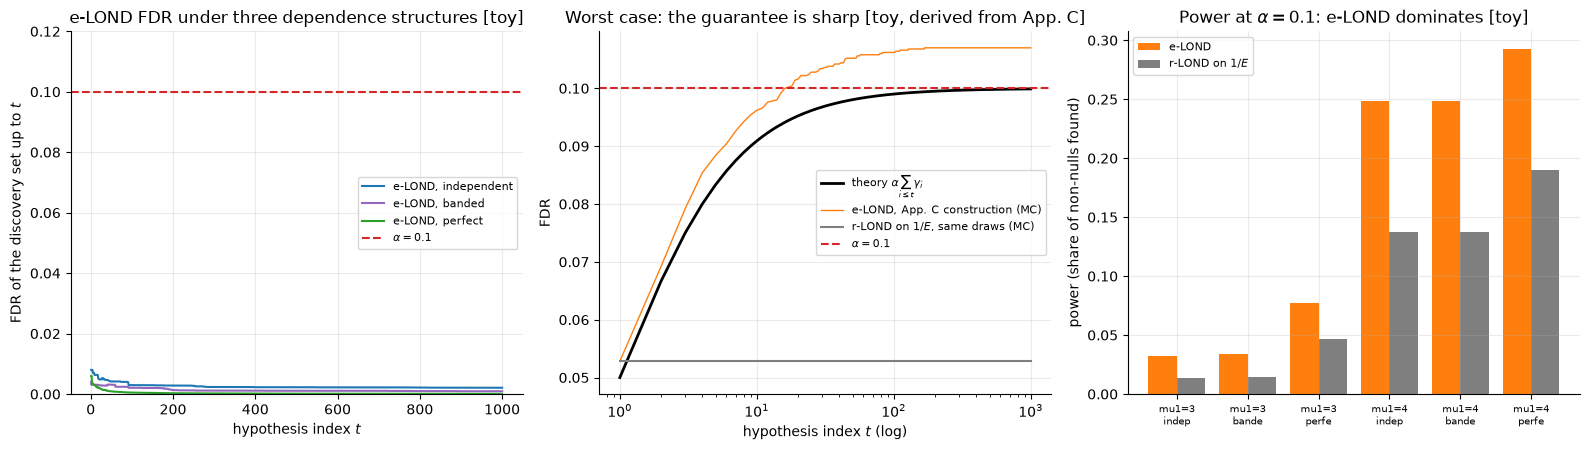

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
x4 = np.arange(1, T4 + 1)
cols = {"independent": PALETTE["cr"], "banded": PALETTE["mix"], "perfect": PALETTE["calib"]}
for dp in DEPS4:
    ax[0].plot(x4, res4[(0.1, 3.0, dp)]["elond"]["fdr_t"], color=cols[dp], label=f"e-LOND, {dp}")
ax[0].axhline(0.1, color=PALETTE["peek"], ls="--", label=r"$\alpha=0.1$")
ax[0].set_ylim(0, 0.12); ax[0].set_xlabel("hypothesis index $t$"); ax[0].set_ylabel("FDR of the discovery set up to $t$")
ax[0].set_title("e-LOND FDR under three dependence structures [toy]"); ax[0].legend(fontsize=8)
sh = res_sh[0.1]
ax[1].plot(x4, sh["theory_t"], color=PALETTE["truth"], lw=2, label=r"theory $\alpha\sum_{i\leq t}\gamma_i$")
ax[1].plot(x4, sh["fdr_t"], color=PALETTE["elond"], lw=1, label="e-LOND, App. C construction (MC)")
ax[1].plot(x4, sh["fdr_r_t"], color=PALETTE["hoeffding"], label=r"r-LOND on $1/E$, same draws (MC)")
ax[1].axhline(0.1, color=PALETTE["peek"], ls="--", label=r"$\alpha=0.1$")
ax[1].set_xscale("log"); ax[1].set_xlabel("hypothesis index $t$ (log)"); ax[1].set_ylabel("FDR")
ax[1].set_title("Worst case: the guarantee is sharp [toy, derived from App. C]"); ax[1].legend(fontsize=8)
labels, pe, pr = [], [], []
for m in MUS4:
    for dp in DEPS4:
        labels.append(f"mu1={m:g}\n{dp[:5]}"); pe.append(res4[(0.1, m, dp)]["elond"]["power"]); pr.append(res4[(0.1, m, dp)]["rlond"]["power"])
xb = np.arange(len(labels))
ax[2].bar(xb - 0.2, pe, 0.4, color=PALETTE["elond"], label="e-LOND"); ax[2].bar(xb + 0.2, pr, 0.4, color=PALETTE["hoeffding"], label=r"r-LOND on $1/E$")
ax[2].set_xticks(xb); ax[2].set_xticklabels(labels, fontsize=7); ax[2].set_ylabel("power (share of non-nulls found)")
ax[2].set_title(r"Power at $\alpha=0.1$: e-LOND dominates [toy]"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. COMBINE: calibeating and multi-calibeating (Chen, Huang, Jordan and Luo)

**Plain statement about the source.** This paper is **purely theoretical: it contains no experiments and releases no code**. Everything below that is run is our own implementation of the paper's algorithms on our own simulator (derived here); the rates are paper facts, our simulated constants are not.

**Protocol (Sec. 2).** At each round the learner sees $N$ external forecasts $q_t^{(n)}$, issues its own $p_t$, then the outcome $y_t$ is revealed and the loss $\ell(p_t,y_t)$ is incurred. The external forecasts and outcomes are generated by an **oblivious adversary**: fixed at time 0 with full knowledge of the algorithm but not of its random bits. So the bounds are worst-case over *fixed* sequences, not over adaptive opponents.

**Quantities (Def. 2.1).** Cumulative loss $L_T(p_{1:T},y_{1:T})=\sum_t\ell(p_t,y_t)$; **refinement score** $R_T=\sum_p n_T(p)\,\ell(\rho_T^p,\rho_T^p)=\sum_p\min_q\sum_{t:p_t=p}\ell(q,y_t)$, the loss of the best constant prediction inside each forecast value; **calibration error** $K_T=L_T-R_T$. For Brier loss (Ex. 2.2) $R_T$ is the weighted within-bin variance and $K_T=\sum_pn_T(p)\|p-\rho_T^p\|^2$, the $\ell_2$-calibration. (The paper's Brier loss is $\|p-y\|_2^2$ on probability vectors; for binary outcomes we use the scalar form $(p-y)^2$, which differs by a constant factor 2.) **Def. 2.4:** a learner is $\alpha(T)$-*calibeating* (or *multi-calibeating* for $N$ forecasters) if for all sequences $L_T(p_{1:T},y_{1:T})\le R_T(q^{(n)}_{1:T},y_{1:T})+\alpha(T)$ for every $n$. In words: whatever the external forecaster does, we do as well as its **refinement score** (what it would score if someone perfectly relabelled its probabilities) up to a small additive term.

**Calibeating equals no-regret learning (Sec. 3).**

> **Theorem 3.1.** "For any proper loss $\ell$ and any online algorithm $\mathcal{A}$ with regret $\alpha(T)$, where $\alpha$ is a concave function, Algorithm 1 is $|Q|\alpha(T/|Q|)$-calibeating."

**Algorithm 1**: run a separate copy of the no-regret learner on the rounds where $q_t$ takes each value $q\in Q$ ($Q$ = set of distinct forecast values). The proof sums per-bin regrets and uses Jensen's inequality. For Brier loss, follow-the-leader (FTL) predicts the empirical mean of past outcomes in the bin. Rates: Cor. 3.2 (bounded proper loss, follow-the-perturbed-leader) $O(\sqrt{|Q|KT})$; **Cor. 3.4** ($\eta$-mixable loss such as Brier or log loss, exponentially weighted online optimization) $O(|Q|\log T)$, and FTL also attains this for Brier; **Thm 3.5 / Cor. 3.7** lower bound $\Omega(|Q|\log(T/|Q|))$ for Brier and log loss, so the rate is tight. Because the rates scale with $|Q|$, a continuous forecast has to be **rounded to a grid of `nbins` values** to make $|Q|$ finite (derived here; the paper notes that non-vacuous bounds need $|Q|=o(T/\log T)$ and discretization).

**Multi-calibeating (Sec. 4).** **Algorithm 2** calibeats each forecaster $n$ with its own Algorithm 1 copy and feeds the $N$ calibeated forecasts to an experts algorithm such as Hedge. **Thm 4.1:** the combination is $(\alpha(T)+\gamma(T))$-multi-calibeating, $\gamma(T)$ being the experts regret. **Cor. 4.2** (bounded loss) $O(\sqrt{T\log N}+\sqrt{|Q|KT})$; **Cor. 4.3** (mixable loss) $O(\log N+|Q|\log T)$; **Cor. 4.6** matching lower bound $\Omega(\log N+|Q|\log(T/|Q|))$ for Brier and log loss. Hedge with $\eta=\sqrt{8\log N/T}$ is the setting the paper's appendix quotes for Algorithm 2 (giving $\gamma(T)=O(\sqrt{T\log N})$); the $\log N$ of Cor. 4.3 needs a constant learning rate matched to the mixability of the loss. For the scalar Brier loss the weighted-average Hedge with constant $\eta=1/2$ is valid because $e^{-\eta(p-y)^2}$ is concave on $[0,1]$ for $\eta\le1/2$ (derived here); we run both learning rates.

**Section 5 (described only, not implemented).** Sec. 5 adds simultaneous calibration. **Thm 5.1:** for Brier loss, any $\varepsilon\in(0,1)$ and reference algorithm $A^*$, Algorithm 3 has expected regret $O(\varepsilon^2T)$ against $A^*$ and, with high probability, calibration rate $O_{K,\log T}(\sqrt T+\varepsilon^{-(K-1)}\log\frac1\varepsilon+\varepsilon^2T)$. It combines a discretization-and-rounding scheme (Lemma 5.5), a Blum-Mansour swap-regret reduction (Lemma 5.6) and a lopsided two-expert algorithm (Lemma 5.7) into a randomized predictor; **Cor. 5.2** gives, for binary Brier loss, the multi-calibeating rate $O(\log N+|Q|\log T)$ together with $\tilde O(\sqrt T)$ $\ell_2$-calibration. We do not implement it; the notebooks use Algorithms 1 and 2.

**Checks (derived here, Brier loss, binary outcomes).** (a) Regret against the refinement score of one miscalibrated forecaster should grow like $\log T$, not $\sqrt T$. (b) A badly calibrated forecaster is strictly beaten, by about $K_T$, once $T$ is large enough for $K_T$ (linear in $T$) to exceed the logarithmic learning cost. (c) Algorithm 2 with $N=5$ forecasters (one informative but overconfident, one noisy, one biased, one useless, one *anti*-informative) should be within $O(\log N+|Q|\log T)$ of the best single refinement score. The bounds are worst-case over oblivious sequences; our i.i.d. simulator is a benign case, so the fitted constants describe the simulator only.

In [20]:
# EXPORT: calibeat
import numpy as np


def calibeat(q, y, nbins=10, prior_count=0.0, prior_mean=0.5):
    """Algorithm 1 of Chen, Huang, Jordan and Luo (calibeating by bin-wise no-regret learning), Brier loss, with
    follow-the-leader (FTL) as the in-bin learner: within each bin the prediction is the running empirical mean of the outcomes
    seen so far in that bin (the FTL/ERM prediction for Brier loss, cf. Foster-Hart). Derived here: the continuous external
    forecast q in [0,1] is rounded to nbins equal-width bins (a finite |Q| <= nbins), an empty bin predicts prior_mean=0.5,
    and prior_count (default 0 = plain FTL) optionally adds pseudo-observations as smoothing.
    q, y: arrays of length T (y in {0,1}). Returns the calibeated forecasts p (T,), fully vectorised per bin."""
    q = np.asarray(q, dtype=float)
    y = np.asarray(y, dtype=float)
    b = np.minimum(np.floor(np.clip(q, 0.0, 1.0) * nbins).astype(int), nbins - 1)
    p = np.empty(len(q))
    for k in np.unique(b):
        idx = np.flatnonzero(b == k)
        s_before = np.concatenate([[0.0], np.cumsum(y[idx])[:-1]])          # outcomes in this bin strictly before each visit
        n_before = np.arange(len(idx), dtype=float)
        den = n_before + prior_count
        p[idx] = np.where(den > 0, (s_before + prior_mean * prior_count) / np.where(den > 0, den, 1.0), 0.5)
    return p

In [21]:
# EXPORT: multi_calibeat
import numpy as np


def multi_calibeat(Q, y, nbins=10, eta=None):
    """Algorithm 2 (multi-calibeating by expert aggregation): calibeat each external forecaster n (row of Q, shape (N, T))
    with Algorithm 1, then aggregate the N calibeated forecasts with Hedge (exponential weights on the running Brier losses;
    the prediction is the weighted average). Depends on the calibeat cell.
    eta: Hedge learning rate. Derived here: None -> 0.5 (the exp-concavity constant of the scalar Brier loss on [0,1], which gives
    regret <= ln(N)/eta, the log N behaviour of Cor. 4.3); a float -> that constant; the string 'sqrt' -> sqrt(8 ln N / T), the rate
    quoted for Alg. 2 in the paper's appendix (regret O(sqrt(T log N)), the bounded-loss route of Cor. 4.2).
    Returns (p (T,), weights (T, N)), weights[t] being the weights used to form p[t]."""
    Q = np.asarray(Q, dtype=float)
    y = np.asarray(y, dtype=float)
    N, T = Q.shape
    if eta is None:
        eta = 0.5
    elif isinstance(eta, str):
        eta = float(np.sqrt(8.0 * np.log(max(N, 2)) / T))
    P = np.stack([calibeat(Q[n], y, nbins=nbins) for n in range(N)], axis=1)          # (T, N) calibeated forecasts
    loss = (P - y[:, None]) ** 2
    cum_before = np.cumsum(loss, axis=0) - loss                                        # losses strictly before round t
    z = -eta * cum_before
    z -= z.max(axis=1, keepdims=True)
    w = np.exp(z)
    w /= w.sum(axis=1, keepdims=True)
    return (w * P).sum(axis=1), w

In [22]:
# Tiny-case tests of calibeat / multi_calibeat (not an export cell).
q_t = np.array([0.42, 0.44, 0.91, 0.43, 0.92, 0.45, 0.93])            # bins 4,4,9,4,9,4,9 with nbins=10
y_t = np.array([1, 0, 1, 1, 0, 0, 1], dtype=float)
p_t = calibeat(q_t, y_t, nbins=10)
expected = np.array([0.5, 1.0, 0.5, 0.5, 1.0, 2 / 3, 0.5])           # empirical mean of earlier outcomes in the same bin, 0.5 if none
check("5a", "calibeat tiny case: empty bin -> 0.5, then the running in-bin mean (FTL)", f"{np.round(p_t, 3).tolist()}", f"{np.round(expected, 3).tolist()}",
      bool(np.allclose(p_t, expected)))
rng_c = np.random.default_rng(SEED + 500)
Yc = (rng_c.random(300) < 0.7).astype(float); Qc = np.vstack([rng_c.random(300), 0.5 * np.ones(300)])
pm, wm = multi_calibeat(Qc, Yc)
check("5b", "multi_calibeat shapes/weights: p (T,), weights (T,N) rows sum to 1, first row uniform",
      f"{pm.shape}, {wm.shape}, row sums in [{wm.sum(1).min():.6f}, {wm.sum(1).max():.6f}], first row {np.round(wm[0], 3).tolist()}",
      "(300,), (300, 2), sums 1, [0.5, 0.5]", pm.shape == (300,) and wm.shape == (300, 2) and np.allclose(wm.sum(1), 1) and np.allclose(wm[0], 0.5))

SELF-CHECK 5a: calibeat tiny case: empty bin -> 0.5, then the running in-bin mean (FTL) -> [0.5, 1.0, 0.5, 0.5, 1.0, 0.667, 0.5] (threshold [0.5, 1.0, 0.5, 0.5, 1.0, 0.667, 0.5]) -> MET
SELF-CHECK 5b: multi_calibeat shapes/weights: p (T,), weights (T,N) rows sum to 1, first row uniform -> (300,), (300, 2), row sums in [1.000000, 1.000000], first row [0.5, 0.5] (threshold (300,), (300, 2), sums 1, [0.5, 0.5]) -> MET


In [23]:
NB5 = 10                                   # bins => |Q| <= 10


def snap(q, nbins=NB5):
    """Round forecasts to bin centres (finite |Q|; derived here)."""
    b = np.minimum(np.floor(np.clip(q, 0, 1) * nbins).astype(int), nbins - 1)
    return (b + 0.5) / nbins


def bins_of(q, nbins=NB5):
    return np.minimum(np.floor(np.clip(q, 0, 1) * nbins).astype(int), nbins - 1)


def refinement(qbins, y, nbins=NB5):
    """R_T for Brier loss (Ex. 2.2): sum over bins of n*ybar*(1-ybar) = weighted within-bin variance (binary y)."""
    n = np.bincount(qbins, minlength=nbins).astype(float)
    s = np.bincount(qbins, weights=y, minlength=nbins)
    return float(np.sum(np.where(n > 0, s - s ** 2 / np.maximum(n, 1), 0.0)))


def calibration_error(qvals, y, nbins=NB5):
    """K_T = sum_bins n (bin_value - ybar)^2 for a forecaster whose values sit on the grid."""
    b = bins_of(qvals, nbins)
    n = np.bincount(b, minlength=nbins).astype(float)
    s = np.bincount(b, weights=y, minlength=nbins)
    val = (np.arange(nbins) + 0.5) / nbins
    return float(np.sum(np.where(n > 0, n * (val - s / np.maximum(n, 1)) ** 2, 0.0)))


def gen_reality(rng, T):
    r = np.clip(rng.beta(2, 2, T), 0.02, 0.98)
    return r, (rng.random(T) < r).astype(float)


# (a) log-T regret against the refinement score of ONE miscalibrated (overconfident) external forecaster
TMAX5, REPS5 = 64_000, 30
CHECK_T = np.array([250, 500, 1000, 2000, 4000, 8000, 16000, 32000, 64000])
reg5 = np.zeros((REPS5, len(CHECK_T))); gain5 = np.zeros((REPS5, len(CHECK_T))); K5 = np.zeros((REPS5, len(CHECK_T)))
Qsize5 = np.zeros(REPS5)
gain_cal = np.zeros(REPS5)
rng5 = np.random.default_rng(SEED + 510)
t_s5 = time.time()
for i in range(REPS5):
    r, y = gen_reality(rng5, TMAX5)
    q = snap(np.clip(0.5 + 1.8 * (r - 0.5) + 0.05 * rng5.standard_normal(TMAX5), 0, 1))     # overconfident, on the grid
    p = calibeat(q, y, nbins=NB5)
    lc = np.cumsum((p - y) ** 2); le = np.cumsum((q - y) ** 2)
    qb = bins_of(q)
    for j, T in enumerate(CHECK_T):
        R = refinement(qb[:T], y[:T])
        reg5[i, j] = lc[T - 1] - R                              # L_T(calibeated) - R_T(external)   (Def. 2.4 quantity)
        gain5[i, j] = le[T - 1] - lc[T - 1]                     # L_T(external) - L_T(calibeated)
        K5[i, j] = calibration_error(q[:T], y[:T])              # K_T of the external forecaster (= L_T - R_T for it)
    Qsize5[i] = len(np.unique(qb))
    # a well-calibrated forecaster for contrast
    qg = snap(np.clip(r + 0.05 * rng5.standard_normal(TMAX5), 0, 1))
    pg = calibeat(qg, y, nbins=NB5)
    gain_cal[i] = np.sum((qg - y) ** 2) - np.sum((pg - y) ** 2)
print(f"(section 5a/5b simulation took {time.time() - t_s5:.1f} s)")
Qm = float(Qsize5.mean())
reg_mean, reg_se = reg5.mean(0), reg5.std(0, ddof=1) / np.sqrt(REPS5)
c_ratio = reg5 / (Qm * np.log(CHECK_T))[None, :]
A_fit, B_fit = np.polyfit(np.log(CHECK_T), reg_mean, 1)              # regret ~ A ln T + B
sq_fit = np.polyfit(np.sqrt(CHECK_T), reg_mean, 1)
res_log = np.sum((reg_mean - (A_fit * np.log(CHECK_T) + B_fit)) ** 2); res_sq = np.sum((reg_mean - (sq_fit[0] * np.sqrt(CHECK_T) + sq_fit[1])) ** 2)
print("TOY numbers (our simulator, scalar Brier loss, |Q| = %.1f distinct bins, 30 replications):" % Qm)
print(f"{'T':>7} {'L-R (mean)':>11} {'s.e.':>7} {'K_T external':>13} {'gain L(ext)-L(cal)':>19} {'L-R over |Q| ln T':>18}")
for j, T in enumerate(CHECK_T):
    print(f"{T:7d} {reg_mean[j]:11.2f} {reg_se[j]:7.2f} {K5[:, j].mean():13.1f} {gain5[:, j].mean():19.1f} {c_ratio[:, j].mean():18.3f}")
print(f"fit  mean(L_T - R_T) ~ {A_fit:.2f} ln T + {B_fit:.2f}  => constant per bin a/|Q| = {A_fit / Qm:.3f}   (residual SS: log model {res_log:.2f}, sqrt model {res_sq:.2f})")
print("PAPER facts (theory only, no experiments): expected calibeating rate O(|Q| log T) for Brier (Cor. 3.4), lower bound Omega(|Q| log(T/|Q|)) (Cor. 3.7)")
c_fit = float(np.max(reg_mean / (Qm * np.log(CHECK_T))))
check("5c", "L_T - R_T (bin-wise FTL, overconfident external forecaster) stays below c*|Q|*ln T: fitted constant c = max over T of mean(L-R)/(|Q| ln T)",
      f"{c_fit:.3f}", "<= 0.5 (per-bin FTL regret on Brier is at most var*ln n <= 0.25 ln n, our threshold is 2x looser)", c_fit <= 0.5)
ratio_growth = reg_mean[-1] / reg_mean[2]
check("5d", "growth is logarithmic, not square-root: mean(L-R) at T=64000 divided by at T=1000 (log model predicts ln64000/ln1000 = 1.60, sqrt model 8.0)",
      f"{ratio_growth:.2f}", "< 3.0 and the log fit's residual SS is lower than the sqrt fit's", ratio_growth < 3.0 and res_log < res_sq)
cross = [int(T) for j, T in enumerate(CHECK_T) if gain5[:, j].mean() > 0]
print(f"crossover: mean gain L(ext)-L(cal) turns positive at T = {cross[0]} (K_T grows linearly in T, the regret only like ln T; at T=250/500 calibeating has not yet paid for its learning cost)")
check("5e", "a badly calibrated forecaster is strictly beaten: L_T(calibeated) < L_T(external) in EVERY replication once K_T dominates the log-T learning cost (T >= 4000 here; the smaller T are printed above, where the early learning cost still shows)",
      f"min gain over replications at T>=4000: {gain5[:, 4:].min():.1f}", "> 0", bool(np.all(gain5[:, 4:] > 0)))
rel = (gain5[:, -1] - K5[:, -1]) / K5[:, -1]
check("5f", "the gain is about the external forecaster's calibration error K_T: |gain - K_T| / K_T at T=64000 (mean over replications)", f"{np.abs(rel).mean():.3f}",
      "<= 0.05 (Def. 2.1: L-R = K; regret adds a small log-T term)", np.abs(rel).mean() <= 0.05)
check("5g", "calibeating a WELL-calibrated forecaster costs at most O(|Q| ln T): mean gain (can be negative) at T=64000 vs -0.5*|Q|*ln T",
      f"{gain_cal.mean():.1f}", f">= {-0.5 * Qm * np.log(TMAX5):.1f}", gain_cal.mean() >= -0.5 * Qm * np.log(TMAX5))

(section 5a/5b simulation took 0.4 s)
TOY numbers (our simulator, scalar Brier loss, |Q| = 10.0 distinct bins, 30 replications):
      T  L-R (mean)    s.e.  K_T external  gain L(ext)-L(cal)  L-R over |Q| ln T
    250       10.32    0.15           4.9                -5.4              0.187
    500       11.87    0.15           8.3                -3.6              0.191
   1000       13.39    0.15          14.9                 1.5              0.194
   2000       14.92    0.15          28.1                13.2              0.196
   4000       16.43    0.15          53.6                37.2              0.198
   8000       17.95    0.15         107.4                89.4              0.200
  16000       19.46    0.15         214.4               194.9              0.201
  32000       20.97    0.15         422.4               401.4              0.202
  64000       22.47    0.15         834.2               811.7              0.203
fit  mean(L_T - R_T) ~ 2.19 ln T + -1.74  => constant per bin

In [24]:
# (c) Algorithm 2 with N = 5 forecasters.
N5, T5m, REPS5m = 5, 20_000, 20
names5 = ["overconfident", "noisy", "biased +0.2", "useless", "anti (1-r)"]
CHK = np.array([500, 1000, 2000, 5000, 10000, 20000])
reg_m = {"const": np.zeros((REPS5m, len(CHK))), "sqrt": np.zeros((REPS5m, len(CHK)))}
w_last = np.zeros((REPS5m, N5)); raw_loss = np.zeros((REPS5m, N5)); refin = np.zeros((REPS5m, N5)); best_idx = np.zeros(REPS5m, int)
rng5m = np.random.default_rng(SEED + 520)
t_m = time.time()
for i in range(REPS5m):
    r, y = gen_reality(rng5m, T5m)
    Q = np.vstack([np.clip(0.5 + 1.8 * (r - 0.5) + 0.05 * rng5m.standard_normal(T5m), 0, 1),
                   np.clip(r + 0.15 * rng5m.standard_normal(T5m), 0, 1),
                   np.clip(r + 0.2, 0, 1),
                   np.clip(0.5 + 0.1 * rng5m.standard_normal(T5m), 0, 1),
                   1.0 - r])
    Qb = np.array([bins_of(Q[n]) for n in range(N5)])
    for key, eta in [("const", None), ("sqrt", "sqrt")]:
        p, w = multi_calibeat(Q, y, nbins=NB5, eta=eta)
        lc = np.cumsum((p - y) ** 2)
        for j, T in enumerate(CHK):
            best_R = min(refinement(Qb[n, :T], y[:T]) for n in range(N5))       # min_n R_T(q^(n)): best single refinement score
            reg_m[key][i, j] = lc[T - 1] - best_R
        if key == "const":
            w_last[i] = w[-1]
    raw_loss[i] = ((Q - y[None, :]) ** 2).sum(1)
    refin[i] = [refinement(Qb[n], y) for n in range(N5)]
    best_idx[i] = int(np.argmin(refin[i]))
print(f"(Algorithm 2 simulations took {time.time() - t_m:.1f} s)")
Qs = float(NB5)
bound = np.log(N5) + Qs * np.log(CHK)                                            # ln N + |Q| ln T
c_m = {k: float(np.max(v.mean(0) / bound)) for k, v in reg_m.items()}
print("TOY numbers (our simulator; Brier loss; N=5 forecasters; 20 replications; |Q| <= 10):")
print(f"{'forecaster':>14} {'raw loss L_T':>13} {'refinement R_T':>15} {'final Hedge weight (eta=0.5)':>29}")
for n in range(N5):
    print(f"{names5[n]:>14} {raw_loss[:, n].mean():13.0f} {refin[:, n].mean():15.0f} {w_last[:, n].mean():29.3f}")
print(f"{'T':>7} {'regret vs best R_T, eta=0.5':>29} {'eta=sqrt(8 lnN/T)':>19} {'ln N + |Q| ln T':>16}")
for j, T in enumerate(CHK):
    print(f"{T:7d} {reg_m['const'][:, j].mean():29.2f} {reg_m['sqrt'][:, j].mean():19.2f} {bound[j]:16.1f}")
print(f"fitted constants  max_T mean-regret / (ln N + |Q| ln T):  eta=0.5: {c_m['const']:.3f}   eta=sqrt(8 ln N/T): {c_m['sqrt']:.3f}")
print("PAPER facts (theory only): multi-calibeating rate O(log N + |Q| log T) for mixable loss (Cor. 4.3), lower bound Omega(log N + |Q| log(T/|Q|)) (Cor. 4.6)")
check("5h", "Algorithm 2 (Hedge eta=0.5): regret vs the best single forecaster's refinement score, fitted constant c in c*(ln N + |Q| ln T)",
      f"{c_m['const']:.3f}", "<= 0.5", c_m["const"] <= 0.5)
check("5i", "regret does not grow like sqrt(T): mean regret at T=20000 over T=1000 (log model ~1.7, sqrt model ~4.5), eta=0.5",
      f"{reg_m['const'][:, -1].mean() / reg_m['const'][:, 1].mean():.2f}", "< 2.5", reg_m["const"][:, -1].mean() / reg_m["const"][:, 1].mean() < 2.5)
check("5j", "the same bound holds with the trace's Hedge rate eta=sqrt(8 ln N/T) (same fitted-constant criterion)", f"{c_m['sqrt']:.3f}", "<= 0.5", c_m["sqrt"] <= 0.5)
check("5k", "calibeating rescues the anti-informative forecaster: its refinement score is the best or within 3% of the best in every replication, while its raw loss is the worst",
      f"refinement gap to best (max) {np.max((refin[:, 4] - refin.min(1)) / refin.min(1)):.3f}; raw loss rank worst in {int(np.sum(raw_loss.argmax(1) == 4))}/{REPS5m}",
      "<= 0.03 and 20/20 worst raw loss", bool(np.max((refin[:, 4] - refin.min(1)) / refin.min(1)) <= 0.03 and np.all(raw_loss.argmax(1) == 4)))

(Algorithm 2 simulations took 0.4 s)
TOY numbers (our simulator; Brier loss; N=5 forecasters; 20 replications; |Q| <= 10):
    forecaster  raw loss L_T  refinement R_T  final Hedge weight (eta=0.5)
 overconfident          4352            4038                         0.000
         noisy          4405            4308                         0.000
   biased +0.2          4742            4025                         0.000
       useless          5201            4998                         0.000
    anti (1-r)          8007            4006                         1.000
      T   regret vs best R_T, eta=0.5   eta=sqrt(8 lnN/T)  ln N + |Q| ln T
    500                          7.99                7.42             63.8
   1000                          8.88                8.88             70.7
   2000                         10.06               10.49             77.6
   5000                         11.55               11.94             86.8
  10000                         12.71               

**How to read this chart**

Left panel: x is the horizon $T$ (log scale), y is $L_T(\text{calibeated})-R_T(\text{external})$ for an overconfident external forecaster, mean over 30 replications with s.e. bars. On a log-x axis the points fall on a straight line: the extra loss over the external forecaster's refinement score grows like $\log T$ (fitted black dashed line), as Cor. 3.4 says, and the best $\sqrt T$ curve (grey dotted) fits visibly worse. Middle panel: the external forecaster's total loss minus the calibeated loss (green) against its calibration error $K_T$ (black dashed), both on log axes. Early on the gain is negative (calibeating pays a learning cost of order $|Q|\ln T$); once $K_T$, which grows linearly in $T$, dominates, the two lines merge: calibeating recovers essentially all of the calibration error, which is how it "beats" a miscalibrated forecast. Right panel: Algorithm 2's regret against the best single forecaster's refinement score for $N=5$ forecasters, for two Hedge learning rates, against a fraction of the $\ln N+|Q|\ln T$ envelope. Both stay far below the envelope and grow slowly. Note that the winner is the *anti-informative* forecaster $1-r$: its raw loss is the worst but its refinement score is the best, so calibeating relabels it into the best forecast. For the project: a signal with good ranking but distorted probabilities is worth correcting online, at a cost that grows only logarithmically; the guarantee is about squared-error loss, not profit.

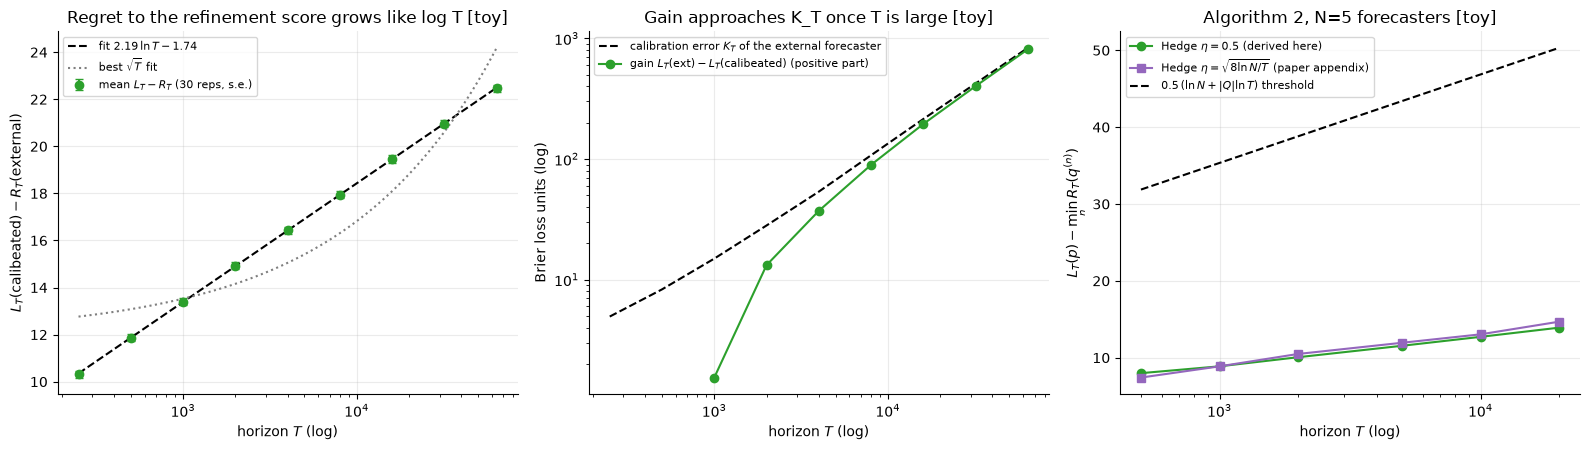

In [25]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
ax[0].errorbar(CHECK_T, reg_mean, yerr=reg_se, fmt="o", color=PALETTE["calib"], capsize=3, label=r"mean $L_T-R_T$ (30 reps, s.e.)")
xs = np.geomspace(CHECK_T[0], CHECK_T[-1], 100)
ax[0].plot(xs, A_fit * np.log(xs) + B_fit, "--", color=PALETTE["truth"], label=rf"fit ${A_fit:.2f}\,\ln T{B_fit:+.2f}$")
ax[0].plot(xs, sq_fit[0] * np.sqrt(xs) + sq_fit[1], ":", color=PALETTE["hoeffding"], label=r"best $\sqrt{T}$ fit")
ax[0].set_xscale("log"); ax[0].set_xlabel("horizon $T$ (log)"); ax[0].set_ylabel(r"$L_T(\mathrm{calibeated})-R_T(\mathrm{external})$")
ax[0].set_title("Regret to the refinement score grows like log T [toy]"); ax[0].legend(fontsize=8)
ax[1].loglog(CHECK_T, K5.mean(0), "--", color=PALETTE["truth"], label=r"calibration error $K_T$ of the external forecaster")
gp = gain5.mean(0)
ax[1].loglog(CHECK_T[gp > 0], gp[gp > 0], "o-", color=PALETTE["calib"], label=r"gain $L_T(\mathrm{ext})-L_T(\mathrm{calibeated})$ (positive part)")
ax[1].set_xlabel("horizon $T$ (log)"); ax[1].set_ylabel("Brier loss units (log)"); ax[1].set_title("Gain approaches K_T once T is large [toy]"); ax[1].legend(fontsize=8)
ax[2].plot(CHK, reg_m["const"].mean(0), "o-", color=PALETTE["calib"], label=r"Hedge $\eta=0.5$ (derived here)")
ax[2].plot(CHK, reg_m["sqrt"].mean(0), "s-", color=PALETTE["mix"], label=r"Hedge $\eta=\sqrt{8\ln N/T}$ (paper appendix)")
ax[2].plot(CHK, 0.5 * bound, "--", color=PALETTE["truth"], label=r"$0.5\,(\ln N+|Q|\ln T)$ threshold")
ax[2].set_xscale("log"); ax[2].set_xlabel("horizon $T$ (log)"); ax[2].set_ylabel(r"$L_T(p)-\min_n R_T(q^{(n)})$")
ax[2].set_title("Algorithm 2, N=5 forecasters [toy]"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. Composition: screen, prove and combine together (derived here)

**What the sources confirm, and what we add.** No paper studies the pipeline below; this section is **derived here** and checked by Monte Carlo. The sources confirm the pieces. (i) A Choe-Ramdas e-process $E_t$ for the weak null satisfies $\mathbb{E}[E_\tau]\le1$ for every stopping time $\tau$ (Eq. 23), and e-LOND asks only for $\mathbb{E}[E_t]\le1$ per hypothesis (Eq. 3), so the e-process **stopped at a stopping time (in particular at a fixed horizon $T$)** is a valid e-value for e-LOND (Xu and Ramdas, Sec. 2 make the same point). (ii) e-LOND controls FDR under arbitrary dependence (Thm 1), and names data reuse across hypotheses as a primary case, so signals evaluated on the **same games** are covered. (iii) A calibeated forecast is **predictable**: Algorithm 1 forms $p_t$ from earlier rounds and $q_t$ before $y_t$ is revealed, so it fits the game filtration of Choe and Ramdas (Sec. 4.2), and with a bounded score (Brier, $|\hat\delta|\le1$) Thms 2 and 3 apply to (calibeated minus raw). What the traces do **not** address: **data-dependent ordering of the hypotheses** (we fix the order a priori, in registration order, and never reorder by results), and anything about money (no margin, odds, stakes, costs or limits; a Brier gain is not profit).

**Design (derived here).** *(a) Screen and prove.* Forty signals are forecasts for the **same** games, all measured against one market forecast. Reality $r_t\in[0.25,0.75]$; the market's error $e_t$ is truncated normal (sd 0.12, $|e_t|\le0.2$), $q_t=r_t+e_t$. A **null signal** copies or reflects the market's error, $p_t=r_t\pm e_t$, so its true gap $\delta_t$ is exactly 0 (the weak null holds with $\Delta_t=0$, the hardest boundary case), with the $\pm$ signs driven by a shared latent factor so the signals are strongly dependent on each other and on the market. A **real edge** shrinks the market's error, $p_t=r_t\pm(1-\theta)e_t$ with $\theta\in\{0.7,0.8,0.9\}$, so $\delta_t=e_t^2(1-(1-\theta)^2)>0$. Six of 40 signals are real, at random positions in the registration order. Each signal's Choe-Ramdas mixture e-process (`cr_log_eprocess`) is evaluated at the horizon $T=5500$ games and the 40 e-values go to `elond` at $\alpha=0.1$; a second variant stops each signal at a **data-dependent** time (first check, every 10 games, with $E_t\ge10^5$, else $T$). We also run an all-null world, place the real edges first or last in the order, and compare with the naive uncorrected one-sided $z$-test. *(b) Combine and prove.* A calibeated forecast (bin-wise FTL on an overconfident raw forecaster) is compared with the raw forecaster: the empirical-Bernstein CS on $\hat\delta_t=S(p_t,y_t)-S(q_t,y_t)$ must cover the true expected gap $\Delta_t$, which the simulator knows.

In [26]:
# 6(a) Composition: K dependent signals -> Choe-Ramdas e-values at a stopping time -> e-LOND in a fixed a-priori order.
K6, T6c, ALPHA6, N_REAL = 40, 5500, 0.1, 6
THETAS = np.array([0.7, 0.8, 0.9, 0.7, 0.8, 0.9])          # error shrinkage of the real-edge signals (derived here)
LOAD = 0.7                                                  # loading of each signal's random sign on a shared latent factor


def gen_signals_th(rng, nb, K, T, real_mask, th):
    """All K signals are forecasts for the SAME games (derived here). Reality r_t in [0.25,0.75]; the market's error e_t is truncated normal
    (sd 0.12, |e|<=0.2), q_t = r_t + e_t. A NULL signal reflects or copies the market error, p = r + s*e with s = +/-1 (so its true gap delta_t is
    exactly 0: the weak null holds with Delta_t = 0); the signs share a latent factor f_t across signals (dependence). A REAL signal shrinks
    the error, p = r + (1-theta)*s*e, so delta_t = e^2 (1-(1-theta)^2) > 0. Returns delta_hat (nb,K,T) = S(p,y)-S(q,y) for Brier S."""
    r = np.clip(0.5 + 0.25 * np.sin(2 * np.pi * np.arange(1, T + 1) / 400.0 + rng.uniform(0, 6.28, (nb, 1, 1))), 0.25, 0.75)
    e = np.clip(0.12 * rng.standard_normal((nb, 1, T)), -0.2, 0.2)
    y = (rng.random((nb, 1, T)) < r).astype(float)
    f = rng.standard_normal((nb, 1, T)); g = rng.standard_normal((nb, K, T))
    s = np.sign(LOAD * f + np.sqrt(1 - LOAD ** 2) * g)
    shrink = np.where(real_mask, 1.0 - th[:, :, None], 1.0)
    p = r + shrink * s * e
    q = r + e
    return (q - y) ** 2 - (p - y) ** 2


def run_pipeline(seed, trials, n_real, batch=5, place="random"):
    rng = np.random.default_rng(seed)
    out = dict(fdp_T=[], fdp_tau=[], fdp_naive=[], pow_T=[], pow_tau=[], pow_naive=[], nd_T=[], nd_tau=[], first_cross=[], logE_null_T=[], logE_real_T=[])
    for b0 in range(0, trials, batch):
        nb = min(batch, trials - b0)
        real_mask = np.zeros((nb, K6, 1), bool)
        th = np.zeros((nb, K6))
        for i in range(nb):                                                        # random positions in the registration order
            pos = rng.choice(K6, n_real, replace=False) if place == "random" else (np.arange(n_real) if place == "first" else K6 - 1 - np.arange(n_real))
            real_mask[i, pos, 0] = True; th[i, pos] = THETAS[:n_real]
        dh = gen_signals_th(rng, nb, K6, T6c, real_mask, th)
        isreal = real_mask[:, :, 0]
        # e-value at the fixed horizon T (a stopping time)
        logE_T = cr_log_eprocess(dh, alpha=0.05, last_only=True)                    # (nb, K)
        E_T = np.exp(np.minimum(logE_T, 700.0))
        dT, _ = elond(E_T, ALPHA6)
        # e-value at a data-dependent stopping time: first t (multiple of 10) with E_t >= 1e5, else T   (crossing via the exact boundary map)
        s_, v_ = intrinsic(dh)
        grid = np.arange(9, T6c, 10)
        cross = s_[..., grid] >= cr_uniform_boundary(v_[..., grid], alpha_side=1e-5, rho=_cr_rho(0.025, 10.0))
        hit = cross.any(axis=-1); first = np.where(hit, np.argmax(cross, axis=-1), len(grid) - 1)
        tau = grid[first]; tau = np.where(hit, tau, T6c - 1)
        s_tau = np.take_along_axis(s_, tau[..., None], -1)[..., 0]; v_tau = np.take_along_axis(v_, tau[..., None], -1)[..., 0]
        E_tau = np.exp(np.minimum(_cr_log_m(s_tau, v_tau, _cr_rho(0.025, 10.0), 2.0), 700.0))
        dtau, _ = elond(E_tau, ALPHA6)
        # naive screen: one-sided z-test on mean delta_hat at T, uncorrected, at 5%
        zn = dh.mean(-1) / (dh.std(-1, ddof=1) / np.sqrt(T6c))
        dn = zn > 1.645
        for name, d in [("T", dT), ("tau", dtau), ("naive", dn)]:
            nd = d.sum(1)
            out["fdp_" + name].extend(((d & ~isreal).sum(1) / np.maximum(nd, 1)).tolist())
            out["pow_" + name].extend((((d & isreal).sum(1)) / max(n_real, 1) if n_real else np.zeros(nb)).tolist() if n_real else [0.0] * nb)
        out["nd_T"].extend(dT.sum(1).tolist()); out["nd_tau"].extend(dtau.sum(1).tolist())
        out["first_cross"].extend(np.where(hit & isreal, tau, -1)[isreal].tolist())
        out["logE_null_T"].extend(logE_T[~isreal][:50].tolist()); out["logE_real_T"].extend(logE_T[isreal].tolist())
    return {k: np.array(v) for k, v in out.items()}

In [27]:
t_s6 = time.time()
TR6 = 300
res6 = run_pipeline(SEED + 600, TR6, N_REAL)
res6_null = run_pipeline(SEED + 601, 200, 0)
res6_first = run_pipeline(SEED + 602, 100, N_REAL, place="first")
res6_last = run_pipeline(SEED + 603, 100, N_REAL, place="last")
print(f"(section 6a simulations took {time.time() - t_s6:.1f} s)")
print(f"TOY numbers (K={K6} signals on the same {T6c} games, {N_REAL} real edges at random positions, alpha={ALPHA6}, e-LOND in registration order):")
print(f"{'pipeline':>46} {'FDR':>7} {'power':>7} {'mean #discoveries':>18}")
for name, r_, key in [("CR e-value at fixed T -> e-LOND", res6, "T"), ("CR e-value at data-dependent tau -> e-LOND", res6, "tau"),
                      ("naive one-sided z-test, no correction", res6, "naive")]:
    print(f"{name:>46} {r_['fdp_' + key].mean():7.4f} {r_['pow_' + key].mean():7.3f} {(r_['nd_' + key].mean() if key != 'naive' else float('nan')):18.2f}")
print(f"{'all-null world, CR e-value at T -> e-LOND':>46} {res6_null['fdp_T'].mean():7.4f} {'-':>7} {res6_null['nd_T'].mean():18.3f}")
print(f"{'all-null world, naive z-test':>46} {res6_null['fdp_naive'].mean():7.4f}")
print(f"real edges registered FIRST: power {res6_first['pow_T'].mean():.3f}; registered LAST: power {res6_last['pow_T'].mean():.3f} (levels shrink with the index t)")
print(f"log E_T (log e-value at the horizon): null signals median {np.median(res6['logE_null_T']):.2f} (99th pct {np.percentile(res6['logE_null_T'], 99):.2f}); real signals median {np.median(res6['logE_real_T']):.1f}")
se6 = lambda a, n: 3 * mc_se(a, n)
check("6a", "composition: FDR of [Choe-Ramdas e-value at fixed horizon T] -> e-LOND (fixed order, 40 dependent signals, same games), 300 trials", f"{res6['fdp_T'].mean():.4f}",
      f"<= alpha + 3 s.e. = {ALPHA6 + se6(ALPHA6, TR6):.3f}", res6["fdp_T"].mean() <= ALPHA6 + se6(ALPHA6, TR6))
check("6b", "composition with a DATA-DEPENDENT stopping time (first t with E_t >= 1e5, else T): FDR", f"{res6['fdp_tau'].mean():.4f}",
      f"<= {ALPHA6 + se6(ALPHA6, TR6):.3f}", res6["fdp_tau"].mean() <= ALPHA6 + se6(ALPHA6, TR6))
check("6c", "all-null world: FDR (= probability of any discovery) of the pipeline, 200 trials", f"{res6_null['fdp_T'].mean():.4f}",
      f"<= {ALPHA6 + se6(ALPHA6, 200):.3f}", res6_null["fdp_T"].mean() <= ALPHA6 + se6(ALPHA6, 200))
print(f"naive uncorrected screen, mixed world: FDR {res6['fdp_naive'].mean():.3f} (dependence makes false positives arrive in clumps, so this average can sit near or below alpha for a given design/seed; it carries no guarantee). All-null world: {res6_null['fdp_naive'].mean():.3f}")
check("6d", "the naive uncorrected z-screen has no FDR guarantee: in the all-null world (where FDR = P(any false discovery)) its FDR exceeds alpha by more than 3 MC s.e.", f"{res6_null['fdp_naive'].mean():.3f}",
      f"> alpha + 3 s.e. = {ALPHA6 + se6(ALPHA6, 200):.3f}", res6_null["fdp_naive"].mean() > ALPHA6 + se6(ALPHA6, 200))
check("6e", "the pipeline finds the real edges (power at this horizon)", f"random order {res6['pow_T'].mean():.2f}", "power >= 0.6", res6["pow_T"].mean() >= 0.6)
_d6 = res6_first["pow_T"].mean() - res6_last["pow_T"].mean()
_se6 = float(np.sqrt(res6_first["pow_T"].var(ddof=1) / len(res6_first["pow_T"]) + res6_last["pow_T"].var(ddof=1) / len(res6_last["pow_T"])))
check("6e2", "registration order matters (e-LOND levels shrink with the index t): edges registered first vs last, power gap in s.e. (with the corrected boundary power is near saturation, so the gap is small)",
      f"first {res6_first['pow_T'].mean():.2f}, last {res6_last['pow_T'].mean():.2f}, gap {_d6:.3f} = {_d6 / max(_se6, 1e-12):.1f} s.e.", "gap > 3 s.e.", _d6 > 3 * _se6)


(section 6a simulations took 6.4 s)
TOY numbers (K=40 signals on the same 5500 games, 6 real edges at random positions, alpha=0.1, e-LOND in registration order):
                                      pipeline     FDR   power  mean #discoveries
               CR e-value at fixed T -> e-LOND  0.0000   0.973               5.84
    CR e-value at data-dependent tau -> e-LOND  0.0000   0.973               5.84
         naive one-sided z-test, no correction  0.1174   1.000                nan
     all-null world, CR e-value at T -> e-LOND  0.0000       -              0.000
                  all-null world, naive z-test  0.2700
real edges registered FIRST: power 1.000; registered LAST: power 0.920 (levels shrink with the index t)
log E_T (log e-value at the horizon): null signals median -2.79 (99th pct 0.16); real signals median 12.7
SELF-CHECK 6a: composition: FDR of [Choe-Ramdas e-value at fixed horizon T] -> e-LOND (fixed order, 40 dependent signals, same games), 300 trials -> 0.0000 (thresh

In [28]:
# 6(b) A calibeated forecast is predictable, so the EB CS on (calibeated - raw) covers the true expected score gap.
T6b, N6b = 6000, 300
tt6 = np.arange(1, T6b + 1)
rng6b = np.random.default_rng(SEED + 630)
miss6 = np.zeros(N6b, bool); lower_pos_T = np.zeros(N6b, bool); first_pos = np.full(N6b, np.nan); Delta_T6 = np.zeros(N6b)
ex6b = None
t_b = time.time()
for i in range(N6b):
    r = np.clip(rng6b.beta(2, 2, T6b), 0.02, 0.98)
    y = (rng6b.random(T6b) < r).astype(float)
    q = snap(np.clip(0.5 + 1.8 * (r - 0.5) + 0.05 * rng6b.standard_normal(T6b), 0, 1))   # miscalibrated raw forecaster (on a grid)
    p = calibeat(q, y, nbins=NB5)                                                          # predictable: uses only rounds < t and q_t
    dhat = (q - y) ** 2 - (p - y) ** 2                                                     # S(p,y) - S(q,y), Brier score S=1-(p-y)^2, positive = calibeated better
    delta = (q - r) ** 2 - (p - r) ** 2                                                    # E_{t-1}[S(p,y)-S(q,y)]: known to the simulator
    Delta = np.cumsum(delta) / tt6
    lo, up = cr_confseq(dhat[None, :], 0.05)
    lo, up = lo[0], up[0]
    miss6[i] = np.any((Delta < lo) | (Delta > up))
    lower_pos_T[i] = lo[-1] > 0
    if np.any(lo > 0): first_pos[i] = int(np.argmax(lo > 0)) + 1
    Delta_T6[i] = Delta[-1]
    if ex6b is None: ex6b = dict(Delta=Delta, lo=lo, up=up, dhat_bar=np.cumsum(dhat) / tt6)
print(f"(section 6b took {time.time() - t_b:.1f} s)")
print(f"TOY numbers: true average gap Delta_T (calibeated minus raw), mean over paths {Delta_T6.mean():.4f}; CS lower bound > 0 at T in {lower_pos_T.mean():.3f} of paths; "
      f"median first round with lower bound > 0: {np.nanmedian(first_pos):.0f}")
check("6f", "EB CS on (calibeated - raw) covers the true expected gap Delta_t at every t: whole-horizon miscoverage, 300 paths x T=6000", f"{miss6.mean():.4f}",
      f"<= 0.05 + 3 s.e. = {0.05 + 3 * mc_se(0.05, N6b):.3f}", miss6.mean() <= 0.05 + 3 * mc_se(0.05, N6b))
check("6g", "the CS proves the calibeating gain (raw forecaster is miscalibrated): fraction of paths with lower bound > 0 at T", f"{lower_pos_T.mean():.3f}", ">= 0.95", lower_pos_T.mean() >= 0.95)

(section 6b took 0.3 s)
TOY numbers: true average gap Delta_T (calibeated minus raw), mean over paths 0.0104; CS lower bound > 0 at T in 1.000 of paths; median first round with lower bound > 0: 3502
SELF-CHECK 6f: EB CS on (calibeated - raw) covers the true expected gap Delta_t at every t: whole-horizon miscoverage, 300 paths x T=6000 -> 0.0000 (threshold <= 0.05 + 3 s.e. = 0.088) -> MET
SELF-CHECK 6g: the CS proves the calibeating gain (raw forecaster is miscalibrated): fraction of paths with lower bound > 0 at T -> 1.000 (threshold >= 0.95) -> MET


**How to read this chart**

Left panel: the distribution of $\log E_T$ (log e-value at the horizon) for null signals (grey) versus real edges (blue), with the level a discovery needs. Under the null the e-value stays near or below 1 ($\log E\le 0$ typically) and rarely exceeds a few units even for 40 dependent signals; real edges reach large values. The orange dashed lines are the e-LOND thresholds $\log\big(1/(\alpha\gamma_t(|R|+1))\big)$ at signal positions $t=1,10,40$: the later a signal is registered, the more evidence it needs, which is why edges registered last are found less often. Middle panel: false discovery rate and power of the pipeline (orange), of the same pipeline with a data-dependent stopping time (purple), and of the naive uncorrected screen (grey), in the mixed world and in the all-null world. The pipeline's FDR sits at or near zero (well below the red $\alpha$ line: the guarantee is an upper bound and is loose here, as in the paper's own simulations), while the naive screen gives a false "winner" in more than a third of all-null worlds. Right panel (one path): the empirical-Bernstein CS on (calibeated minus raw) covers the true gap (black) at every round and its lower bound crosses 0 (marker), the CS "proves" that the calibeated forecast beats the raw one, exactly the kind of statement the business wants to make and, unlike a fixed-time interval, it survives being checked after every game. Everything here is a Brier-score statement in a simulator; it is not evidence about profit.

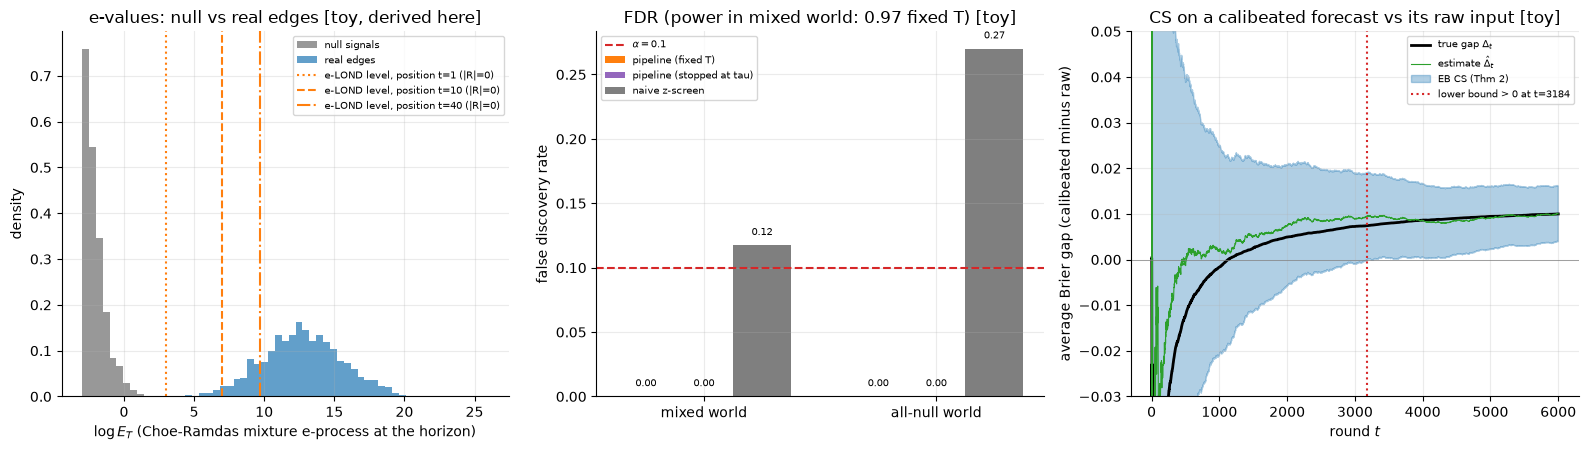

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
bins_ = np.linspace(-3, 26, 60)
ax[0].hist(res6["logE_null_T"], bins=bins_, color=PALETTE["hoeffding"], alpha=0.8, density=True, label="null signals")
ax[0].hist(res6["logE_real_T"], bins=bins_, color=PALETTE["cr"], alpha=0.7, density=True, label="real edges")
for pos_, ls in [(1, ":"), (10, "--"), (40, "-.")]:
    ax[0].axvline(np.log(pos_ * (pos_ + 1) / ALPHA6), color=PALETTE["elond"], ls=ls, label=f"e-LOND level, position t={pos_} (|R|=0)")
ax[0].set_xlabel(r"$\log E_T$ (Choe-Ramdas mixture e-process at the horizon)"); ax[0].set_ylabel("density")
ax[0].set_title("e-values: null vs real edges [toy, derived here]"); ax[0].legend(fontsize=7)
lab = ["mixed world", "all-null world"]
xb = np.arange(2); w = 0.25
vals = {"pipeline (fixed T)": ([res6["fdp_T"].mean(), res6_null["fdp_T"].mean()], PALETTE["elond"]),
        "pipeline (stopped at tau)": ([res6["fdp_tau"].mean(), res6_null["fdp_tau"].mean()], PALETTE["mix"]),
        "naive z-screen": ([res6["fdp_naive"].mean(), res6_null["fdp_naive"].mean()], PALETTE["hoeffding"])}
for k, (name, (v, c_)) in enumerate(vals.items()):
    ax[1].bar(xb + (k - 1) * w, v, w, color=c_, label=name)
ax[1].axhline(ALPHA6, color=PALETTE["peek"], ls="--", label=r"$\alpha=0.1$")
for k, (name, (v, c_)) in enumerate(vals.items()):
    for j in range(2): ax[1].text(xb[j] + (k - 1) * w, v[j] + 0.008, f"{v[j]:.2f}", ha="center", fontsize=7)
ax[1].set_xticks(xb); ax[1].set_xticklabels(lab); ax[1].set_ylabel("false discovery rate")
ax[1].set_title(f"FDR (power in mixed world: {res6['pow_T'].mean():.2f} fixed T) [toy]"); ax[1].legend(fontsize=7)
x6 = np.arange(1, T6b + 1); e6 = ex6b
ax[2].plot(x6, e6["Delta"], color=PALETTE["truth"], lw=2, label=r"true gap $\Delta_t$")
ax[2].plot(x6, e6["dhat_bar"], color=PALETTE["calib"], lw=0.8, label=r"estimate $\hat\Delta_t$")
ax[2].fill_between(x6, e6["lo"], e6["up"], color=PALETTE["cr"], alpha=0.35, label="EB CS (Thm 2)")
if np.any(e6["lo"] > 0):
    tc = int(np.argmax(e6["lo"] > 0)) + 1
    ax[2].axvline(tc, color=PALETTE["peek"], ls=":", label=f"lower bound > 0 at t={tc}")
ax[2].axhline(0, color="grey", lw=0.5); ax[2].set_ylim(-0.03, 0.05); ax[2].set_xlabel("round $t$"); ax[2].set_ylabel("average Brier gap (calibeated minus raw)")
ax[2].set_title("CS on a calibeated forecast vs its raw input [toy]"); ax[2].legend(fontsize=7)
plt.tight_layout(); plt.show()

## Recap

* **Prove (Choe and Ramdas).** The empirical-Bernstein confidence sequence, built from the gamma-exponential mixture boundary (Eq. 15, 16, 41, 43), covered the moving gap $\Delta_t$ at every round in simulation (zero whole-horizon miscoverage against the 5% budget; conservative), while a fixed-time interval checked at every round reached a cumulative miscoverage of about 0.5 by $T=10^4$, our toy number next to the paper's quoted "about 50%". The EB CS was tighter than the Hoeffding CS at every checked horizon. The weak-null e-process obeyed $P(\sup_tE_t\ge1/\alpha)\le\alpha$, did not reject on the Eq. 22 example where a strong-null-style test does, and was **exactly dual** to the CS (CS excludes 0 iff $E_t\ge2/\alpha$) whenever both use the same mixture. Predictable subsequences (App. F.1) are covered only when the rule is fixed in advance.
* **Screen (Xu and Ramdas).** e-LOND kept FDR below $\alpha$ at every $t$ under independence, banded dependence and perfect dependence, contained the discovery set of r-LOND applied to $1/E$ on every draw, and reached $\alpha\sum_i\gamma_i$ on the App. C worst-case construction (0.107 against a theoretical 0.0999 at $\alpha=0.1$, within Monte Carlo error), so the bound is sharp. Its price is power: the level at position $t$ decays like $\gamma_t$, so registration order matters.
* **Combine (Chen et al.).** Bin-wise follow-the-leader calibeating stayed within a logarithmic term of the external forecaster's refinement score, recovered its calibration error once $T$ was large enough, and Hedge over calibeated forecasters stayed within $O(\log N+|Q|\log T)$ of the best single refinement score. The paper itself has no experiments and no code; these are our implementations of its algorithms.
* **Composition (derived here).** Choe-Ramdas e-values at a fixed or data-dependent stopping time, fed to e-LOND in a fixed a-priori order, controlled FDR for 40 dependent signals evaluated on the same games; the EB CS on (calibeated minus raw) covered the true expected gap.
* **Limits.** Everything is a simulation; guarantees describe the simulator's Brier scores and are descriptive, not predictive (Choe and Ramdas). None of the three papers models margin, stakes, costs or limits, so a proven Brier edge is not a proven profit. The traces do not cover data-dependent hypothesis ordering, or a monitor that changes the tested hypothesis after looking at data. The reusable functions defined here (`cr_uniform_boundary`, `cr_confseq`, `cr_log_eprocess`, `elond`, `rlond`, `calibeat`, `multi_calibeat`) are the building blocks for Notebooks 2 and 3.